# Stress Response Study: the GB battery fleet under system tightness

**Research premise.** Batteries are dispatched for commercial return, but commercial price
signals and physical system stress are not the same thing. This notebook asks what the real
GB battery fleet actually *did* during the tightest periods on the system, using the
operator's own scarcity measures rather than a price-derived proxy.

**Population.** Every BM-registered GB battery site — the **87-site census**
reconstructed in notebook 06 — not the smaller population the live dashboard renders. That
distinction is the difference between a claim about the GB fleet and a claim about a sample of
it: the dashboard shows only sites whose energy capacity someone publishes *and* which cycle
enough to be priced from wholesale and BM alone, so a stress-response result computed on those
would describe part of the market and be quietly generalised to all of it. `fleet.registry`
states that population and its size.

**Four questions.**

1. **Physical availability** — is the fleet present when the system needs it? Net discharge,
   declared availability and (inferred) state of charge during the top-1% loss-of-load
   probability periods, the bottom-1% de-rated margin periods, and the periods Capacity
   Market Notices warned about.
2. **Stress modification** — does the fleet mitigate or amplify tightness? Net fleet demand
   (charge − discharge) by de-rated-margin band, and how often the fleet is *charging* while
   the margin is critically thin.
3. **Dynamic foresight** — does the fleet respond before or after stress materialises?
   How early tightness was visible in the forecast prints, and how state of charge and
   dispatch evolve into a critical period versus matched control periods.
4. **Consumer value** — does battery discharge suppress price spikes? Cashout spike
   frequency by fleet-discharge quartile, holding system stress constant.

**Data.** 2018-01-01 → 2026-08-24, GB, all public and free: Elexon FUELHH / ITSDO / LoLP-DRM /
per-BMU PN, MELS, MILS / B1770 cashout, Sheffield Solar PV_Live, and the NESO Capacity
Market Notice register. No API keys, no prices from subscription feeds — which is why this
window can be eight winters long rather than the 60 days of
[`04_alignment_gap.ipynb`](04_alignment_gap.ipynb).

**Relationship to notebook 04.** 04 prices the *alignment gap* of a profit-optimal benchmark
against a relative (top-decile residual load) stress signal, over the ~60 days for which
free day-ahead prices exist. This notebook drops the benchmark and the prices, and instead
measures the **real fleet** against **operator-grade scarcity signals** over eight winters.
The two are complements: 04 says what alignment costs, 05 says what the fleet actually did.

**Stated up front.** Physical Notifications are served final-only — Elexon does not publish
revision history — so Section 6 measures *realised dispatch* differences around a scarcity
signal, not proven reaction to it. Fleet state of charge is **inferred** from PNs, never
observed. Both are treated as first-class limitations, not footnotes.

In [1]:
%matplotlib inline

import datetime as dt
import importlib.util
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# Repo root, found by walking up to the marker file, so the notebook runs the
# same whether it is opened from its own directory or from the repo root.
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists()
)
sys.path.insert(0, str(REPO_ROOT))

from research.figexport import save_poster_fig

from fleet import census
from fleet import performance as fleet_perf
from fleet.population import census_population

# ── Frozen vintage ──────────────────────────────────────────────────────────
# The registers behind the census and NESO's auction results are both live, so
# an unpinned run returns a different population and different revenue every
# day, and every number below moves with it. This notebook fixes both at
# 2026-08-24 — the same date notebooks 04, 05 and 06 all use, so the three are
# directly comparable. The library default is unpinned; this is a notebook
# decision, set here rather than in the repo.
#
# To move the analysis on: change this date, re-run, and update any figure of
# this notebook's that README.md, DATA_ARCHITECTURE.md or the poster quote.
census.SNAPSHOT = dt.date(2026, 8, 24)
from live import resilience
from live.assets import bess_config

# The store builder is a script, not a package module — load it by path so the
# notebook and a background backfill run share exactly one implementation.
_spec = importlib.util.spec_from_file_location(
    "build_stress_store", REPO_ROOT / "scripts" / "build_stress_store.py"
)
bss = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(bss)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# Consistent hexes with the dashboard's design system (same dict as notebook 04).
C = {
    "ink":       "#0b0b0b",
    "da":        "#2a78d6",
    "discharge": "#1baf7a",
    "charge":    "#eb6834",
    "cost":      "#e34948",
    "mid":       "#c98500",
    "soc":       "#4a3aa7",
    "ghost":     "#c3c2b7",
    "stress":    (0.89, 0.29, 0.28, 0.14),
    "surplus":   (0.11, 0.69, 0.48, 0.12),
}

# --- Window and knobs ------------------------------------------------------
# DRY_RUN builds a two-week store so the whole notebook runs in minutes; the
# full window is eight winters and takes hours to fetch on a cold cache.
DRY_RUN = False

# The window is PINNED, not relative to today. A rolling `today() - 1` end date
# silently invalidates the store at every midnight, which re-fetches the days
# whose feeds publish late and quietly moves every number in the notebook —
# results must not depend on when the notebook happened to be run. Extend the
# study by editing this date and rebuilding deliberately.
# 2018-01-01 is the data floor, not a preference. Physical Notifications, the
# declared-limit feeds and PV_Live all reach back to 2016, but Elexon's
# loss-of-load / de-rated-margin prints — the operator-grade scarcity signal this
# whole study conditions on — are complete only from 2018. Eight winters rather
# than three, and the extra five span the era when GB batteries lived in Dynamic
# Containment and were routinely skipped in the Balancing Mechanism.
FULL_START = dt.date(2018, 1, 1)
FULL_END = dt.date(2026, 8, 24)
WINDOW_END = FULL_END
WINDOW_START = (WINDOW_END - dt.timedelta(days=13)) if DRY_RUN else FULL_START
# The population studied. The live dashboard renders a subset — sites whose
# energy capacity is published, because its cycle and duration cells divide by
# MWh, and which cycle enough to be priced at all. This notebook takes the full
# BM-registered census (notebook 06), because a claim about "the GB fleet under
# stress" computed on a subset is a claim about the subset.
#
# Each population writes its own store — a store holds site rows for exactly the
# fleet it was built from, so sharing one directory would silently change what
# the curated results mean.
POP = census_population()
STORE = bss.store_for(POP)
if DRY_RUN:
    STORE = STORE / "dry_run"

# --- Analysis constants ----------------------------------------------------
DRM_BANDS = [0, 1000, 2000, 4000, 7000, np.inf]
DRM_BAND_LABELS = ["<1,000", "1–2k", "2–4k", "4–7k", ">7k"]
SPIKE_LEVELS = (500.0, 1000.0)
DRM_CRITICAL_MW = 1000.0     # RQ2/RQ3 "critically thin margin"
HH = 0.5                     # hours per settlement period
LOOKBACK_HH = 24             # 12 h of half-hours for SoC run-up (RQ3b)
EVENT_HH = 12                # ±6 h around a trigger for the event study (RQ3c)
MAX_CONTROLS = 5             # matched controls per event
MIN_N_DIST = 10              # below this a set is a case study, not a distribution
SOC_CLAMP_MAX = 0.5          # SoC usability: at most half the time pinned at a bound
CYCLES_MIN = fleet_perf.ANCILLARY_CYCLES_THRESHOLD  # 0.3 cycles/day

CFG = bess_config()
ETA_C = CFG["charge_efficiency"]
ETA_D = CFG["discharge_efficiency"]

SITE_MW = {s.site: s.power_mw for s in POP.sites}
SITE_MWH = {s.site: s.capacity_mwh for s in POP.sites}

# Energy capacity is published only through Capacity Market agreements, and those
# match a BM Unit for a minority of census sites. Power is known for every site,
# so MW-normalised metrics span the whole fleet; anything divided by MWh — cycles
# and inferred state of charge above all — is restricted to this subset and says
# so wherever it appears. Guessing a duration would put a fabricated denominator
# under a headline number.
SITES_WITH_MWH = {s for s, mwh in SITE_MWH.items() if mwh == mwh}

# Composition controls. A fixed panel is the strictest control for a changing
# fleet, but over eight winters it shrinks to the handful of sites that existed
# in 2018 and still run today — a valid control and a thin one. The modern panel
# trades window length for population, so the two together bracket the question
# rather than resting it on either.
MODERN_PANEL_START = dt.date(2023, 10, 1)


def skip(reason):
    '''Uniform "nothing to work with" notice.'''
    print(f"n=0 — skipped: {reason}")


DAYS = bss.window_days(WINDOW_START, WINDOW_END)
print(f"Window     : {WINDOW_START} → {WINDOW_END}  ({len(DAYS)} days)"
      f"{'  [DRY RUN]' if DRY_RUN else ''}")
print(f"Store      : {STORE}")
print(f"Efficiency : ηc={ETA_C:.2f} ηd={ETA_D:.2f}")
print(f"Population : {POP.name} — {len(POP)} sites, {len(POP.bmu_ids())} BM Units, "
      f"{sum(SITE_MW.values()):,.0f} MW declared")
print(f"Energy cap : known for {len(SITES_WITH_MWH)} of {len(SITE_MW)} sites "
      f"({100 * len(SITES_WITH_MWH) / len(SITE_MW):.0f}%) — MWh-normalised metrics "
      f"use this subset only")

Worksheet row for GB-BESS-WOLVB (Wolverhampton West BESS) needs review: 310 MWh over 56.0 MW declared implies 5.5 h, longer than any priced census site. Self-consistent with the duration recorded, so the agreement check cannot judge it — confirm the figure covers this BM Unit and not the wider project.


Window     : 2018-01-01 → 2026-08-24  (3158 days)
Store      : /Users/abhinav/Documents/code/power-trading/data/processed/stress_study_census
Efficiency : ηc=0.94 ηd=0.94
Population : census — 87 sites, 124 BM Units, 6,234 MW declared
Energy cap : known for 65 of 87 sites (75%) — MWh-normalised metrics use this subset only


## Methodology definitions

Everything the poster needs to state, fixed before any number is computed.

| Term | Definition |
|---|---|
| **Window** | 2018-01-01 → 2026-08-24, UTC settlement days, half-hourly grid |
| **Residual load** | ITSDO transmission demand − FUELHH wind − PV_Live embedded solar; a missing component propagates as NaN and the period is excluded, never zero-filled |
| **Sign convention** | Physical Notification positive = export (discharge). Fleet net MW = Σ site PN MW; negative fleet net MW = the fleet is a *load* |
| **Online site** | A settlement day between that site's first and last observed PN day |
| **Normalised fleet response** | fleet net MW ÷ online nameplate MW — the fleet roughly doubled over the window, so absolute MW is not comparable across it |
| **Core panel** | Sites online within 30 days of the window start and still active at the end; used where a fixed composition matters |
| **Availability factor** | Σ site MELS (declared export limit) ÷ Σ online nameplate MW |
| **C_LOLP** | Loss-of-load probability ≥ 1e-4 — one in ten thousand. Absolute, so it means the same in every window |
| **C_DRM** | De-rated margin < 1 GW — the operator's own critical line |
| **C_DRM1000** | De-rated margin < 1,000 MW |
| **C_CMN** | Period overlaps an issued Capacity Market Notice window (half-open intervals; an open notice covers its target period) |
| **Cannibalistic charging** | Share of a set's periods with fleet net MW < 0 |
| **SoC inference (primary)** | Per site, `SoC(t+1) = clip(SoC(t) + (charge·ηc − discharge/ηd)·0.5h, 0, capacity)`, starting at 50%, η from the benchmark config. Clamps at the bounds act as re-anchors |
| **SoC usability** | A site's inferred SoC enters fleet aggregates only if it cycles ≥ 0.3×/day (below that the site is ancillary-parked and PNs miss its throughput) and is clamped ≤ 50% of the time |
| **SoC sensitivity** | Re-anchor to 50% daily at 04:00 UTC; headline SoC numbers are reported under both schemes and disagreement is reported, not resolved silently |
| **Matched controls** | Same half-hour of day, same calendar month (any year in window), on a day containing no critical period; ≤ 5 per event |
| **Trigger (RQ3c)** | Publish time of the first forecast print for a period with DRM < 1,000 MW or LoLP > 0 |
| **Spike** | Cashout price > £500/MWh and > £1,000/MWh (GB has a single cashout price post-2015, so SBP alone suffices) |
| **Volatility Dampening Index** | Within DRM-decile bins: (P95 − P50 of cashout \| bottom discharge tercile) − (P95 − P50 \| top tercile), averaged weighted by period count. Positive ⇒ price tails are compressed when the fleet discharges, at equal system stress |

## 1. Data acquisition and coverage

Eight feeds, day-cached, assembled once into tidy parquet tables by
`scripts/build_stress_store.py`. Everything downstream reads those tables, so the analysis
re-runs in seconds. Days that fail are recorded and skipped rather than sinking the build —
the coverage table below is the honest statement of what the study is actually computed on.

In [2]:
if not bss.store_is_current(STORE, DAYS):
    print("Store missing or stale — building (this is the slow, network-bound step).")
    bss.build_store(DAYS, STORE, population=POP)

S = bss.load_store(STORE)
system    = S["system"]
prints    = S["lolpdrm_prints"]
pn        = S["fleet_pn"]
mels      = S["fleet_mels"]
mils      = S["fleet_mils"]
sbp       = S["sbp"]
cmn       = S["cmn"]
coverage  = S["coverage"]

# The store is a cache of raw per-site profiles; the population defines the
# analysis. They can disagree — a store built before a site was reclassified
# still holds its rows — so the population is applied at load rather than
# assumed. Anything the current population does not recognise is dropped here
# instead of silently arriving with a null nameplate.
_known = set(SITE_MW)
for _table in ("fleet_pn", "fleet_mels", "fleet_mils"):
    frame = S[_table]
    dropped = sorted(set(frame["site"]) - _known)
    if dropped:
        S[_table] = frame[frame["site"].isin(_known)]
        if _table == "fleet_pn":
            print(f"Dropped {len(dropped)} site(s) the current population excludes: "
                  f"{', '.join(dropped)}\n")

system    = S["system"]
prints    = S["lolpdrm_prints"]
pn        = S["fleet_pn"]
mels      = S["fleet_mels"]
mils      = S["fleet_mils"]

for name, frame in S.items():
    print(f"{name:16s} {len(frame):>9,} rows")

system             151,495 rows
lolpdrm_prints     750,729 rows
fleet_pn         4,359,935 rows
fleet_mels       4,364,621 rows
fleet_mils       4,351,753 rows
sbp                151,563 rows
cmn                     25 rows
coverage             3,158 rows


         days_present  days_missing   first_day    last_day coverage
system           3158             0  2018-01-01  2026-08-24   100.0%
lolpdrm          3158             0  2018-01-01  2026-08-24   100.0%
pn               3141            17  2018-01-01  2026-08-24    99.5%
mels             3150             8  2018-01-01  2026-08-24    99.7%
mils             3140            18  2018-01-01  2026-08-24    99.4%
sbp              3158             0  2018-01-01  2026-08-24   100.0%


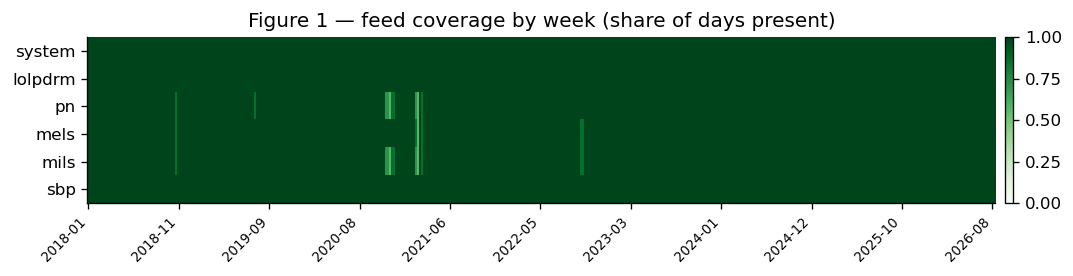


Sparsest feed: mils — 18 missing day(s). Analyses below filter to periods where the feed they need is present.


In [3]:
FEEDS = [c for c in ("system", "lolpdrm", "pn", "mels", "mils", "sbp") if c in coverage]
cov = coverage.copy()
cov["date"] = pd.to_datetime(cov["date"])

summary = pd.DataFrame({
    "days_present": [int(cov[f].sum()) for f in FEEDS],
    "days_missing": [int((~cov[f]).sum()) for f in FEEDS],
    "first_day": [cov.loc[cov[f], "date"].min().date() if cov[f].any() else None for f in FEEDS],
    "last_day":  [cov.loc[cov[f], "date"].max().date() if cov[f].any() else None for f in FEEDS],
}, index=FEEDS)
summary["coverage"] = (summary["days_present"] / len(cov)).map(lambda v: f"{v:.1%}")
print(summary.to_string())

# Figure 1 — coverage by feed and week. Gaps that matter show up as vertical bands.
weekly = cov.set_index("date")[FEEDS].resample("W").mean()
fig, ax = plt.subplots(figsize=(9, 2.4))
im = ax.imshow(weekly.T.values, aspect="auto", cmap="Greens", vmin=0, vmax=1,
               extent=[0, len(weekly), len(FEEDS), 0], interpolation="nearest")
ax.set_yticks(np.arange(len(FEEDS)) + 0.5)
ax.set_yticklabels(FEEDS)
step = max(1, len(weekly) // 10)
ax.set_xticks(np.arange(0, len(weekly), step) + 0.5)
ax.set_xticklabels([d.strftime("%Y-%m") for d in weekly.index[::step]], rotation=45,
                   ha="right", fontsize=8)
ax.set_title("Figure 1 — feed coverage by week (share of days present)")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
plt.tight_layout()
plt.show()

if summary["days_missing"].sum() == 0:
    print("\nEvery feed covers every day in the window.")
else:
    worst = summary["days_missing"].idxmax()
    print(f"\nSparsest feed: {worst} — {summary.loc[worst, 'days_missing']} missing day(s). "
          "Analyses below filter to periods where the feed they need is present.")

## 2. Fleet buildout and normalisation

The GB grid-scale battery fleet roughly doubled over this window, and the census is a
July-2026 snapshot — several tracked sites (Coalburn, Kilmarnock South) simply did not exist
in 2023. Comparing absolute fleet MW across the window would therefore measure commissioning,
not behaviour. Every later fleet statistic is normalised by **online nameplate MW**, and a
fixed **core panel** is available where composition must be held constant.

Pre-battery history removed for 3 site(s) across PN, MELS and MILS (309,734 periods):
  Fiddler's Ferry 2        counted only from 2020-03-18
  Fiddler's Ferry GT 3     counted only from 2020-03-19
  Fiddler's Ferry GT2      counted only from 2019-07-16



                                 first_pn     last_pn  power_mw  capacity_mwh   core  modern
site                                                                                        
Coalburn 1                     2025-10-31  2026-08-24   512.377      1000.000  False   False
Monk Fryston BESS BMU-1        2026-05-08  2026-08-24   320.000       640.000  False   False
Kilmarnock South               2025-07-31  2026-08-24   312.566       600.000  False   False
T_THURB-1                      2024-11-28  2026-08-24   300.000       600.000  False   False
Uskmouth                       2025-09-23  2026-08-24   230.000       460.000  False   False
Blackhillock                   2024-05-01  2026-08-24   208.840       400.000  False   False
Thornton                       2024-12-16  2026-08-24   200.000       400.000  False   False
Ferrybridge                    2024-11-29  2026-08-24   152.000       300.000  False   False
Wilton                         2024-06-01  2026-08-24   150.000       

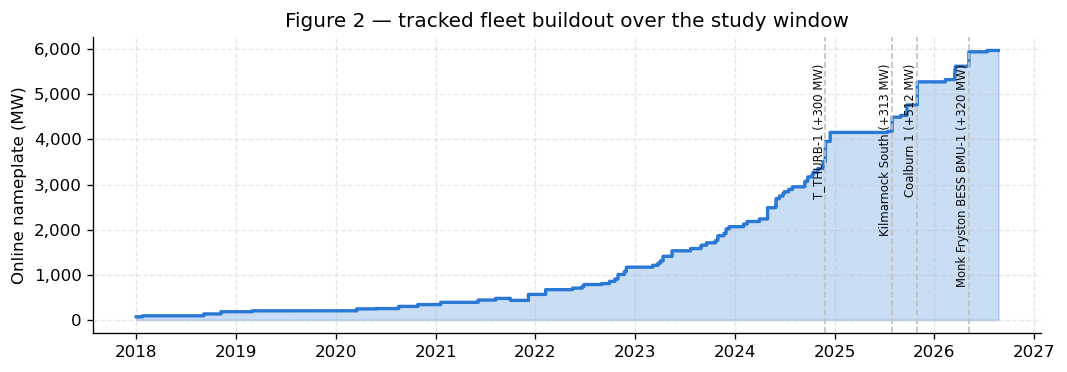

In [4]:
pn = pn.copy()
pn["time"] = pd.to_datetime(pn["time"], utc=True)
pn["date"] = pn["time"].dt.date

# Connection points get reused. Reaching back to 2018 picks up whatever plant
# held a BM Unit before the battery did — Fiddler's Ferry exported 1,385 MW
# against a 41 MW nameplate until the coal station closed in March 2020. The
# asset ID is stable across owner and name changes by design; it cannot see a
# change of technology at the same connection point, so the physics decides
# instead and each site's history starts after the last period it did something
# no battery could.
ERA_START = fleet_perf.battery_era_start(pn, SITE_MW)


def _trim_to_battery_era(frame):
    """Drop a site's rows from before its battery took over the connection."""
    frame = frame.copy()
    frame["time"] = pd.to_datetime(frame["time"], utc=True)
    keep = pd.Series(True, index=frame.index)
    for site, valid_from in ERA_START.items():
        keep &= ~((frame["site"] == site) & (frame["time"] < valid_from))
    return frame[keep]


if ERA_START:
    # Every per-site feed, not just the notified position. The declared-limit
    # feeds carry the same contamination — the coal station declared export
    # limits too — and leaving them in inflates the availability factor above
    # 100%, which is how this was caught.
    before = {"PN": len(pn), "MELS": len(mels), "MILS": len(mils)}
    pn, mels, mils = (_trim_to_battery_era(f) for f in (pn, mels, mils))
    removed = before["PN"] - len(pn) + before["MELS"] - len(mels) + before["MILS"] - len(mils)
    print(f"Pre-battery history removed for {len(ERA_START)} site(s) across PN, MELS and "
          f"MILS ({removed:,} periods):")
    for site, valid_from in sorted(ERA_START.items()):
        print(f"  {site:24s} counted only from {valid_from.date()}")
    print()

span = pn.groupby("site")["date"].agg(first_pn="min", last_pn="max")
span["power_mw"] = span.index.map(SITE_MW)
span["capacity_mwh"] = span.index.map(SITE_MWH)

day_index = pd.DatetimeIndex(sorted(pd.to_datetime(cov["date"]).unique()), name="date").tz_localize("UTC")
online_mw = pd.Series(0.0, index=day_index)
online_n = pd.Series(0, index=day_index)
for site, row in span.iterrows():
    live_days = (day_index.date >= row["first_pn"]) & (day_index.date <= row["last_pn"])
    online_mw[live_days] += row["power_mw"]
    online_n[live_days] += 1

tail_cutoff = WINDOW_END - dt.timedelta(days=7)
span["core"] = (span["first_pn"] <= WINDOW_START + dt.timedelta(days=30)) & (
    span["last_pn"] >= tail_cutoff
)
span["modern"] = (span["first_pn"] <= MODERN_PANEL_START + dt.timedelta(days=30)) & (
    span["last_pn"] >= tail_cutoff
)
CORE_SITES = sorted(span.index[span["core"]])
MODERN_SITES = sorted(span.index[span["modern"]])

print(span.sort_values("power_mw", ascending=False).to_string())
print(f"\nOnline nameplate: {online_mw.iloc[0]:,.0f} MW → {online_mw.iloc[-1]:,.0f} MW "
      f"({online_mw.iloc[-1] / max(online_mw.iloc[0], 1) - 1:+.0%}), "
      f"{int(online_n.iloc[0])} → {int(online_n.iloc[-1])} sites")
print(f"Core panel      : {len(CORE_SITES)} sites, "
      f"{span.loc[span['core'], 'power_mw'].sum():,.0f} MW "
      f"(present since {WINDOW_START} — strictest control, thinnest sample)")
print(f"Modern panel    : {len(MODERN_SITES)} sites, "
      f"{span.loc[span['modern'], 'power_mw'].sum():,.0f} MW "
      f"(present since {MODERN_PANEL_START} — shorter window, larger sample)")

# Figure 2 — tracked fleet buildout.
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.fill_between(online_mw.index, online_mw.values, step="post",
                color=C["da"], alpha=0.25)
ax.step(online_mw.index, online_mw.values, where="post", color=C["da"], lw=2)
for site, row in span.sort_values("power_mw", ascending=False).head(4).iterrows():
    first = pd.Timestamp(row["first_pn"], tz="UTC")
    if first > day_index[0]:
        ax.axvline(first, color=C["ghost"], lw=1, ls="--")
        ax.annotate(f"{site} (+{row['power_mw']:.0f} MW)", (first, online_mw.max() * 0.95),
                    rotation=90, va="top", ha="right", fontsize=7, color=C["ink"])
ax.set_ylabel("Online nameplate (MW)")
ax.set_title("Figure 2 — tracked fleet buildout over the study window")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout()
plt.show()

## 3. System stress: classification and conditioning sets

Two independent views of stress. The **relative** one (notebook 04's signal) is the top decile
of residual load within the window. The **operator-grade** ones come from Elexon's loss-of-load
probability and de-rated margin prints and from the NESO Capacity Market Notice register — these
are absolute, account for outages, interconnectors and de-rating, and are what the system
operator itself acts on.

The four conditioning sets below define every "under stress" statistic in the rest of the
notebook. Their sizes are printed before any statistic is computed on them, and any set with
fewer than ten members is labelled a **case study** rather than a distribution — a rule fixed
here, before the counts are known.

In [5]:
flags = resilience.classify_periods(system["residual_mw"])

# Latest print per settlement period (shortest horizon wins) — the same rule as
# src.data.preprocess.process_lolpdrm, applied to the store's print-level table.
final = (prints.sort_values(["horizon", "publish_time"], ascending=[True, False])
               .drop_duplicates("time")
               .set_index("time")[["lolp", "drm_mw"]]
               .sort_index())

cmn_issued = cmn[cmn["type_id"] == 1] if not cmn.empty else cmn
cmn_expiry = cmn[cmn["type_id"] == 4] if not cmn.empty else cmn
tiers = resilience.classify_tiers(flags, final, cmn_issued)
grid = tiers.index
known = tiers["tier2_known"]
lolp, drm = tiers["lolp"], tiers["drm_mw"]

# Absolute thresholds, not percentiles of this window.
#
# Percentiles look rigorous and are a trap the moment two windows are compared:
# a looser era gets a looser bar, so a stronger response can be manufactured by
# the definition rather than the fleet. These levels mean the same thing in 2018
# and in 2026, which is what makes notebooks 07 and 08 able to compare eras at
# all. The cost is that the scarcest sets are tiny — which is a finding about GB,
# not a defect, and section 3 states it.
# LoLP > 0 is deliberately absent. A non-zero loss-of-load probability covers
# 6% of all periods and touches a third of all days — that is the operator's
# model returning a number, not the system being scarce, and reporting it beside
# genuine scarcity sets invites a reader to treat the two alike. One in ten
# thousand is the weakest line worth calling risk.
C_LOLP = (lolp >= 1e-4).fillna(False)
# Only the operator's own line survives. A 3 GW threshold was tried and dropped:
# it is 8.4% margin against the demand of the periods it selects — comfortable by
# any system-operator convention — and the number itself came from this window's
# 1st percentile (3,236 MW) rounded down. That is a percentile wearing an
# absolute number's clothes, which is the thing this notebook stopped doing.
C_DRM = (drm < DRM_CRITICAL_MW).fillna(False)   # 2.6% margin — genuinely tight
C_CMN = tiers["tier3"].fillna(False)
C_TIER1 = tiers["tier1"].fillna(False)

# Not scarcity. The top decile of demand net of wind and solar is when the fleet
# works hardest, not when the system is at risk — the overlap table below shows
# it catches barely half of the periods the operator flags. Named for what it is.
SETS = {
    "All periods": pd.Series(True, index=grid),
    "Utilisation (residual decile)": C_TIER1,
    "LoLP >= 1e-4": C_LOLP,
    "DRM < 1 GW": C_DRM,
    "CMN issued": C_CMN,
}
CRITICAL = (C_LOLP | C_DRM | C_CMN).fillna(False)

print(f"Classified periods : {len(grid):,}  ({known.sum():,} with a LoLP/DRM print)")
print("LoLP rule          : LoLP >= 1e-4 — absolute, identical in every window")
print(f"DRM rule           : < {DRM_CRITICAL_MW:,.0f} MW — the operator's critical line   "
      f"|   DRM min: {drm.min():,.0f} MW")
print(f"Critical union     : {int(CRITICAL.sum())} periods\n")
print(pd.Series({k: int(v.sum()) for k, v in SETS.items()}, name="periods").to_string())

overlap = pd.DataFrame(
    {a: {b: int((SETS[a] & SETS[b]).sum()) for b in SETS} for a in SETS}
)
print("\nOverlap (periods in both):")
print(overlap.to_string())

tightest = drm.idxmin()
print(f"\nTightest period in window : {tightest:%Y-%m-%d %H:%M} — "
      f"DRM {drm[tightest]:,.0f} MW, LoLP {lolp[tightest]:.1%}")

# Anchor check against the window's Capacity Market Notice evening. Note the
# margin that night was 1,003.5 MW — three megawatts *above* the 1,000 MW line,
# which is why the sub-1GW set is smaller than the notice count suggests and is
# treated as a case study below rather than a distribution.
anchor_cmn = pd.Timestamp("2025-01-08T16:30:00Z")   # the notice's target period
anchor_tight = pd.Timestamp("2025-01-08T17:00:00Z")  # that evening's tightest half-hour
if anchor_tight in grid:
    assert C_CMN[anchor_cmn], "the 2025-01-08 CMN target period should be flagged"
    assert C_LOLP[anchor_tight], "2025-01-08 17:00 should carry a non-zero LoLP"
    print(f"Anchor OK                 : CMN target {anchor_cmn:%H:%M} flagged; "
          f"{anchor_tight:%H:%M} DRM {drm[anchor_tight]:,.0f} MW, "
          f"LoLP {lolp[anchor_tight]:.1%}")
else:
    print("Anchor 2025-01-08 not in window (dry run) — skipping anchor assertions.")

for name, m in SETS.items():
    n = int(m.fillna(False).sum())
    if 0 < n < MIN_N_DIST:
        print(f"NOTE: {name} has n={n} (< {MIN_N_DIST}) — reported as a case study, "
              "not a distribution.")

Classified periods : 150,843  (150,672 with a LoLP/DRM print)
LoLP rule          : LoLP >= 1e-4 — absolute, identical in every window
DRM rule           : < 1,000 MW — the operator's critical line   |   DRM min: -400 MW
Critical union     : 2076 periods

All periods                      150843
Utilisation (residual decile)     15088
LoLP >= 1e-4                       2075
DRM < 1 GW                           39
CMN issued                           13

Overlap (periods in both):
                               All periods  Utilisation (residual decile)  LoLP >= 1e-4  DRM < 1 GW  CMN issued
All periods                         150843                          15088          2075          39          13
Utilisation (residual decile)        15088                          15088          1111          25          10
LoLP >= 1e-4                          2075                           1111          2075          39          12
DRM < 1 GW                              39                           

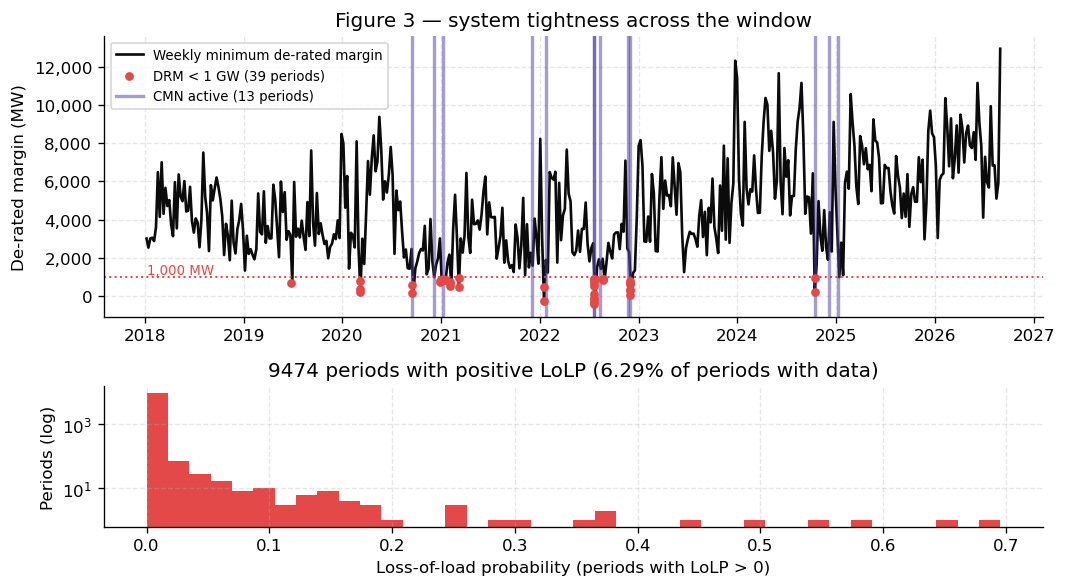

Tight periods by calendar year:
      DRM<1GW  LoLP>0
year                 
2018        0     160
2019        1     859
2020        7    1209
2021        8    1516
2022       21    3041
2023        0    1333
2024        2     660
2025        0     505
2026        0     191


In [6]:
# Figure 3 — where the tight periods actually are.
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=False,
                         gridspec_kw={"height_ratios": [2, 1]})

ax = axes[0]
weekly_min = drm.resample("W").min()
ax.plot(weekly_min.index, weekly_min.values, color=C["ink"], lw=1.6,
        label="Weekly minimum de-rated margin")
ax.axhline(DRM_CRITICAL_MW, color=C["cost"], ls=":", lw=1.2)
ax.annotate(f"{DRM_CRITICAL_MW:,.0f} MW", (weekly_min.index[0], DRM_CRITICAL_MW),
            fontsize=8, color=C["cost"], va="bottom")
tight = drm[C_DRM]
if len(tight):
    ax.scatter(tight.index, tight.values, s=18, color=C["cost"], zorder=3,
               label=f"DRM < 1 GW ({len(tight)} periods)")
cmn_times = grid[C_CMN]
if len(cmn_times):
    for t in cmn_times:
        ax.axvline(t, color=C["soc"], lw=2, alpha=0.5)
    ax.plot([], [], color=C["soc"], lw=2, alpha=0.5,
            label=f"CMN active ({len(cmn_times)} periods)")
ax.set_ylabel("De-rated margin (MW)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Figure 3 — system tightness across the window")

ax = axes[1]
positive = lolp[lolp > 0]
if len(positive):
    ax.hist(positive.values, bins=40, color=C["cost"])
    ax.set_yscale("log")
    ax.set_xlabel("Loss-of-load probability (periods with LoLP > 0)")
    ax.set_ylabel("Periods (log)")
    ax.set_title(f"{len(positive)} periods with positive LoLP "
                 f"({len(positive) / max(int(known.sum()), 1):.2%} of periods with data)")
else:
    ax.text(0.5, 0.5, "No period with LoLP > 0 in this window",
            ha="center", va="center", transform=ax.transAxes, color=C["ink"])
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

by_winter = pd.DataFrame({
    "DRM<1GW": drm[C_DRM].groupby(drm[C_DRM].index.year).size(),
    "LoLP>0": lolp[lolp > 0].groupby(lolp[lolp > 0].index.year).size(),
}).fillna(0).astype(int)
by_winter.index.name = "year"
print("Tight periods by calendar year:")
print(by_winter.to_string() if len(by_winter) else "  none")

## 4. RQ1 — Physical availability: is the fleet there when the system needs it?

Three measures per conditioning set, all normalised for fleet growth:

* **Net response** — fleet net MW per MW of online nameplate. Positive = the fleet is
  exporting into the tight period; negative = it is drawing from it.
* **Availability factor** — declared export limit (MELS) per MW online. This is *declared*
  capability, not proven output: it is what the system operator could see as available.
* **State of charge** — inferred from Physical Notifications (never observed), so it carries
  a usability filter and a sensitivity check. The energy behind the power is the whole
  question: a fleet at 20% SoC entering a stress block cannot deliver for long.

In [7]:
for frame in (mels, mils):
    frame["time"] = pd.to_datetime(frame["time"], utc=True)

online_at = pd.Series(online_mw.reindex(grid.normalize()).to_numpy(), index=grid)
fleet_net = pn.groupby("time")["mw"].sum().reindex(grid)
fleet_mel = mels.groupby("time")["mw"].sum().reindex(grid)
fleet_mil = mils.groupby("time")["mw"].sum().reindex(grid)

norm_net = fleet_net / online_at.replace(0, np.nan)
avail_factor = fleet_mel / online_at.replace(0, np.nan)
headroom_mw = fleet_mel - fleet_net.clip(lower=0)


def infer_soc(mw, capacity_mwh, reanchor=False):
    '''Inferred state of charge (fraction) before each period, from PN MW.

    Returns (series, clamp_fraction). The clip at 0/capacity is what keeps the
    integration from drifting away over months; the clamp fraction reports how
    often that safety net was actually load-bearing, which is the diagnostic
    that decides whether a site's inferred SoC is usable at all.
    '''
    vals = np.nan_to_num(mw.to_numpy(dtype=float))
    idx = mw.index
    out = np.empty(len(vals))
    level = 0.5 * capacity_mwh
    clamped = 0
    for i in range(len(vals)):
        if reanchor and idx[i].hour == 4 and idx[i].minute == 0:
            level = 0.5 * capacity_mwh
        out[i] = level
        v = vals[i]
        new = level + (max(-v, 0.0) * ETA_C - max(v, 0.0) / ETA_D) * HH
        if new < 0.0 or new > capacity_mwh:
            clamped += 1
        level = min(max(new, 0.0), capacity_mwh)
    return pd.Series(out / capacity_mwh, index=idx), clamped / max(len(vals), 1)


wide = pn.pivot_table(index="time", columns="site", values="mw", aggfunc="sum")
soc_cols, soc_anchor_cols, diag_rows = {}, {}, []
skipped_no_mwh: list[str] = []
for site in wide.columns:
    cap = SITE_MWH.get(site)
    # `not cap` does not reject a nan — nan is truthy — so unknown energy
    # capacity has to be tested for explicitly. Without this, a census site with
    # no published duration would divide through by nan and contribute a column
    # of silent nulls to the fleet state-of-charge instead of being excluded.
    if cap is None or cap != cap or cap <= 0:
        skipped_no_mwh.append(site)
        continue
    lo = pd.Timestamp(span.loc[site, "first_pn"], tz="UTC")
    hi = pd.Timestamp(span.loc[site, "last_pn"], tz="UTC") + pd.Timedelta(days=1)
    sub = grid[(grid >= lo) & (grid < hi)]
    if len(sub) < 48:
        continue
    series = wide[site].reindex(sub).fillna(0.0)
    soc, clamp = infer_soc(series, cap)
    soc_anchor, _ = infer_soc(series, cap, reanchor=True)
    discharge_mwh = series.clip(lower=0).sum() * HH
    cycles_day = discharge_mwh / cap / (len(sub) * HH / 24.0)
    usable = (cycles_day >= CYCLES_MIN) and (clamp <= SOC_CLAMP_MAX)
    soc_cols[site], soc_anchor_cols[site] = soc, soc_anchor
    diag_rows.append({"site": site, "capacity_mwh": cap, "cycles_per_day": cycles_day,
                      "clamp_frac": clamp, "usable_soc": usable, "periods": len(sub)})

soc_diag = pd.DataFrame(diag_rows).set_index("site").sort_values("cycles_per_day",
                                                                ascending=False)
USABLE_SOC = list(soc_diag.index[soc_diag["usable_soc"]])
soc_df = pd.DataFrame(soc_cols)
soc_anchor_df = pd.DataFrame(soc_anchor_cols)


def _fleet_soc(frame):
    if not USABLE_SOC:
        return pd.Series(index=grid, dtype=float)
    sub = frame[USABLE_SOC].reindex(grid)
    w = pd.Series({s: SITE_MWH[s] for s in USABLE_SOC})
    num = sub.mul(w, axis=1).sum(axis=1, min_count=1)
    den = sub.notna().mul(w, axis=1).sum(axis=1)
    return num / den.replace(0, np.nan)


fleet_soc = _fleet_soc(soc_df)
fleet_soc_anchor = _fleet_soc(soc_anchor_df)

if skipped_no_mwh:
    mw_skipped = sum(SITE_MW.get(s, 0.0) for s in skipped_no_mwh)
    print(f"State of charge is undefined for {len(skipped_no_mwh)} of {len(wide.columns)} "
          f"active sites ({mw_skipped:,.0f} MW) with no published energy capacity. "
          f"They are excluded from every SoC and cycles figure and remain in all "
          f"MW-normalised ones.\n")

print(soc_diag.round(3).to_string())
print(f"\nSoC-usable sites: {len(USABLE_SOC)}/{len(soc_diag)} "
      f"({', '.join(USABLE_SOC) if USABLE_SOC else 'none'})")
if len(USABLE_SOC) == 0:
    skip("no site passed the SoC usability filter — SoC statistics below are unavailable")
else:
    corr = fleet_soc.corr(fleet_soc_anchor)
    print(f"Primary vs daily-re-anchored fleet SoC: correlation {corr:+.2f}, "
          f"mean gap {abs(fleet_soc - fleet_soc_anchor).mean():.1%}")

State of charge is undefined for 20 of 83 active sites (634 MW) with no published energy capacity. They are excluded from every SoC and cycles figure and remain in all MW-normalised ones.

                               capacity_mwh  cycles_per_day  clamp_frac  usable_soc  periods
site                                                                                        
Erskine BESS                         30.000           1.696       0.229        True     2014
Roaring Hill BESS                    74.985           1.570       0.221        True    47373
Blackhillock                        400.000           1.564       0.326        True    40606
North Tawton BESS                    30.000           1.444       0.201        True     7630
Little Raith BESS                    98.000           1.417       0.251        True    48285
Richborough                         100.000           1.132       0.243        True    47901
Chapel Farm BESS                     84.000           1.110       0

In [8]:
# Stress as events, not as isolated half-hours.
#
# Every figure so far treats a tight settlement period as an independent
# observation. But the mechanism the counterfactual points at is temporal: the
# battery empties while the system is still tight. That is invisible in a
# per-period average and only appears once consecutive tight periods are joined
# into one event and the fleet is followed through it.
BRIDGE_HH = 2          # periods of relief that do not end an event (1 hour)
MIN_EVENT_HH = 2       # ignore single-period blips: an "event" needs an hour
FLOOR_BAND = 0.05      # fleet_soc is a fraction: "at the floor" means within 5 pts

crit = pd.Series(CRITICAL, index=grid).fillna(False)
# Bridge short gaps, so a one-period dip below threshold mid-event does not
# split one three-hour event into two shorter ones.
bridged = crit.rolling(BRIDGE_HH + 1, center=True, min_periods=1).max().astype(bool)
bridged = bridged & crit.rolling(2 * BRIDGE_HH + 1, center=True, min_periods=1).max().astype(bool)
block = (bridged != bridged.shift(fill_value=False)).cumsum()[bridged]

event_rows = []
for _, idx in bridged[bridged].groupby(block):
    times = idx.index
    if len(times) < MIN_EVENT_HH:
        continue
    t0, t1 = times[0], times[-1]
    soc0 = fleet_soc.reindex([t0]).iloc[0]
    during = norm_net.reindex(times)
    soc_path = fleet_soc.reindex(times)
    # When does the fleet hit its floor? Use the lowest SoC it reaches, and the
    # first period within 5 points of it — "empty" for a fleet is not zero.
    floor = soc_path.min()
    at_floor = soc_path[soc_path <= floor + FLOOR_BAND]
    event_rows.append({
        "start": t0,
        "hours": len(times) * 0.5,
        "soc_at_onset": soc0,
        "soc_at_end": soc_path.iloc[-1] if len(soc_path) else np.nan,
        "mean_response": during.mean(),
        "first_half_response": during.iloc[: max(len(during) // 2, 1)].mean(),
        "second_half_response": during.iloc[len(during) // 2 :].mean(),
        "hours_to_floor": (at_floor.index[0] - t0).total_seconds() / 3600
                          if len(at_floor) else np.nan,
    })

events_df = pd.DataFrame(event_rows).dropna(subset=["mean_response"])
print(f"Stress events (bridged, >= {MIN_EVENT_HH * 0.5:.0f}h): {len(events_df)}")
if len(events_df):
    print(f"  median duration       : {events_df['hours'].median():.1f} h "
          f"(max {events_df['hours'].max():.1f} h)")
    print(f"  median SoC at onset   : {events_df['soc_at_onset'].median():.0%}")
    print(f"  response, first half  : {events_df['first_half_response'].mean():+.3f} MW/MW")
    print(f"  response, second half : {events_df['second_half_response'].mean():+.3f} MW/MW")
    decay = (events_df["second_half_response"].mean()
             - events_df["first_half_response"].mean())
    print(f"  decay across the event: {decay:+.3f} MW/MW")


Stress events (bridged, >= 1h): 433


  median duration       : 3.0 h (max 16.0 h)
  median SoC at onset   : 61%
  response, first half  : +0.062 MW/MW
  response, second half : +0.055 MW/MW
  decay across the event: -0.007 MW/MW


RQ1 — fleet response by conditioning set
                                    n  net_MW_per_MW  median_MW_per_MW  discharging_%  avail_factor  mean_SoC  mean_SoC_anchored
set                                                                                                                             
All periods                    150843          0.003             0.000          0.315         0.443     0.560              0.477
Utilisation (residual decile)   15088          0.030             0.000          0.475         0.470     0.530              0.491
LoLP >= 1e-4                     2075          0.060             0.027          0.870         0.413     0.569              0.451
DRM < 1 GW                         39          0.051             0.033          0.949         0.460     0.644              0.481
CMN issued                         13          0.099             0.090          1.000         0.401     0.555              0.452

LoLP >= 1e-4 (n=2075): net +0.060 MW/MW online vs +0.00

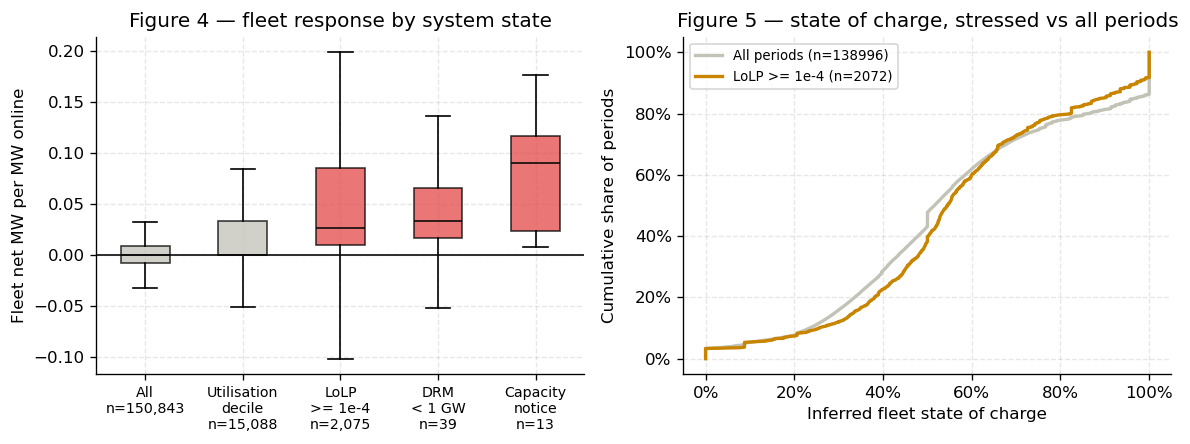

In [9]:
def set_stats(mask, name):
    m = mask.fillna(False)
    n = int(m.sum())
    if n == 0:
        return {"set": name, "n": 0}
    return {
        "set": name,
        "n": n,
        "net_MW_per_MW": float(norm_net[m].mean()),
        "median_MW_per_MW": float(norm_net[m].median()),
        "discharging_%": float((fleet_net[m] > 0).mean()),
        "avail_factor": float(avail_factor[m].mean()),
        "mean_SoC": float(fleet_soc[m].mean()) if len(USABLE_SOC) else np.nan,
        "mean_SoC_anchored": float(fleet_soc_anchor[m].mean()) if len(USABLE_SOC) else np.nan,
    }


rq1 = pd.DataFrame([set_stats(m, k) for k, m in SETS.items()]).set_index("set")
print("RQ1 — fleet response by conditioning set")
print(rq1.round(3).to_string())

baseline = rq1.loc["All periods"]
for name in ("LoLP >= 1e-4", "DRM < 1 GW", "CMN issued"):
    row = rq1.loc[name]
    if row["n"] == 0:
        skip(f"{name} is empty in this window")
        continue
    tag = " [case study]" if row["n"] < MIN_N_DIST else ""
    print(f"\n{name} (n={int(row['n'])}){tag}: net {row['net_MW_per_MW']:+.3f} MW/MW online "
          f"vs {baseline['net_MW_per_MW']:+.3f} baseline · "
          f"discharging in {row['discharging_%']:.0%} of periods · "
          f"availability {row['avail_factor']:.0%}"
          + (f" · mean SoC {row['mean_SoC']:.0%}" if len(USABLE_SOC) else ""))

plot_sets = {k: v for k, v in SETS.items() if int(v.fillna(False).sum()) >= 5}
if len(plot_sets) < 2:
    skip("fewer than two conditioning sets have ≥5 periods — no distribution figure")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    data = [norm_net[m.fillna(False)].dropna().values for m in plot_sets.values()]
    bp = axes[0].boxplot(data, vert=True, patch_artist=True, showfliers=False,
                         medianprops={"color": C["ink"]})
    for patch, name in zip(bp["boxes"], plot_sets):
        patch.set_facecolor(C["cost"] if name not in ("All periods", "Utilisation (residual decile)")
                            else C["ghost"])
        patch.set_alpha(0.75)
    axes[0].axhline(0, color=C["ink"], lw=1)
    # Short, upright labels with thousands separators. The conditioning-set keys
    # are long enough that rotating them at 7pt makes the axis unreadable at
    # poster distance, and rotation is what forces the small size in the first
    # place — horizontal labels can simply be bigger.
    SHORT = {
        "All periods": "All",
        "Utilisation (residual decile)": "Utilisation\ndecile",
        "LoLP >= 1e-4": "LoLP\n>= 1e-4",
        "DRM < 1 GW": "DRM\n< 1 GW",
        "CMN issued": "Capacity\nnotice",
    }
    axes[0].set_xticklabels(
        [f"{SHORT.get(k, k)}\nn={int(v.fillna(False).sum()):,}" for k, v in plot_sets.items()],
        rotation=0, ha="center", fontsize=8.5,
    )
    axes[0].set_ylabel("Fleet net MW per MW online")
    axes[0].set_title("Figure 4 — fleet response by system state")

    ax = axes[1]
    if len(USABLE_SOC):
        # Only two curves now. The margin sets are too small to draw a
        # distribution from — DRM < 1 GW is 39 periods in eight years — so the
        # comparison is the operator's probability signal against the baseline.
        for name, colour in (("All periods", C["ghost"]),
                             ("LoLP >= 1e-4", C["mid"])):
            m = SETS[name].fillna(False)
            vals = fleet_soc[m].dropna().sort_values()
            if len(vals) < 5:
                continue
            ax.plot(vals.values, np.linspace(0, 1, len(vals)), color=colour, lw=2,
                    label=f"{name} (n={len(vals)})")
        ax.set_xlabel("Inferred fleet state of charge")
        ax.set_ylabel("Cumulative share of periods")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.legend(fontsize=8)
        ax.set_title("Figure 5 — state of charge, stressed vs all periods")
    else:
        ax.text(0.5, 0.5, "No SoC-usable sites", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    # Print-resolution export for the poster: fleet net response across stress tiers.
save_poster_fig(fig, "nb05_fig4_response_by_system_state")

plt.show()

### Sensitivity: what the energy-capacity denominator is worth

Everything above that divides by energy capacity — cycles per day, inferred state of charge,
and the usability filter that decides which sites contribute to either — depends on a number
Elexon does not publish. Three sources supply it, in order of precedence: the curated
registry, operator disclosures researched by hand, and the Capacity Market.

The third understates, for two compounding reasons. Its MW is what the operator entered into
the auction rather than what the site can export, and its duration is a band the operator
chose to bid into, where a longer band is a firmer obligation under stress.

This cell prices that choice. It recomputes the same statistics against the
Capacity-Market-only denominators the study would have used before the operator research, so
the shift is stated rather than asserted — including how many sites cross the cycling
threshold that decides whether their state of charge is used at all.

In [10]:
from fleet import census as _census, coverage as _cov

# The denominators this study would have had before any operator research:
# registry figures plus the Capacity Market, and nothing else.
_before = _cov.enrich_with_capacity_market(
    _census.census_sites(), _census.fetch_cm_storage()
).set_index("site_name")["capacity_mwh"]
MWH_BEFORE = {s: v for s, v in _before.items() if v == v}

print("--- Energy-capacity denominator: before and after the operator research ---\n")
print(f"{'sites with a defined MWh':38s} CM only {len(MWH_BEFORE):>3}   now {len(SITES_WITH_MWH):>3}")

# Two distinct effects, and the larger one is easy to miss. A site whose
# denominator merely *changed* shifts its own statistics; a site that had no
# denominator at all was absent from every cycles and state-of-charge figure,
# and now appears. The second is what the research mostly bought.
newly, moved = [], []
for site, d in soc_diag.iterrows():
    old = MWH_BEFORE.get(site)
    days = d["periods"] * HH / 24.0
    discharge = d["cycles_per_day"] * d["capacity_mwh"] * days
    if old is None or old != old:
        newly.append({"site": site, "cap": d["capacity_mwh"], "mw": SITE_MW.get(site),
                      "cycles": d["cycles_per_day"], "usable": bool(d["usable_soc"])})
    elif not np.isclose(old, d["capacity_mwh"]):
        moved.append({"site": site, "cap_before": old, "cap_now": d["capacity_mwh"],
                      "cycles_before": discharge / old / days,
                      "cycles_now": d["cycles_per_day"]})
newly, moved = pd.DataFrame(newly), pd.DataFrame(moved)

print(f"\n1. Sites that had no denominator at all and now do: {len(newly)}"
      f"  ({newly['mw'].sum():,.0f} MW)" if len(newly) else "\n1. No newly-priced sites")
if len(newly):
    print(f"   of which pass the usability filter and enter the SoC figures: "
          f"{int(newly['usable'].sum())}")
    print(newly.nlargest(8, "mw")[["site", "mw", "cap", "cycles", "usable"]]
          .round(2).to_string(index=False))

print(f"\n2. Sites whose denominator changed: {len(moved)}")
if len(moved):
    ratio = (moved["cycles_before"] / moved["cycles_now"]).median()
    print(f"   the Capacity Market figure overstated their cycling by a median "
          f"{100 * (ratio - 1):.0f}%")
    print(moved.round(3).to_string(index=False))
    crossed = moved[(moved["cycles_before"] >= CYCLES_MIN) & (moved["cycles_now"] < CYCLES_MIN)]
    print(f"   pushed over the {CYCLES_MIN} cycles/day usability threshold by the old "
          f"figure alone: {len(crossed)}")

print(f"\n3. Resulting state")
print(f"   {'SoC-usable sites':36s} {len(USABLE_SOC):>6}")
print(f"   {'fleet mean SoC, DRM < 1 GW':36s} {fleet_soc[C_DRM].mean():>6.1%}")
print(f"   {'fleet mean SoC, LoLP >= 1e-4':36s} {fleet_soc[C_LOLP].mean():>6.1%}")
print(f"   {'still without a denominator':36s} {len(SITE_MW) - len(SITES_WITH_MWH):>6}")

--- Energy-capacity denominator: before and after the operator research ---

sites with a defined MWh               CM only  42   now  65

1. Sites that had no denominator at all and now do: 44  (4,391 MW)
   of which pass the usability filter and enter the SoC figures: 29
                   site     mw    cap  cycles  usable
             Coalburn 1 512.38 1000.0    0.13   False
Monk Fryston BESS BMU-1 320.00  640.0    0.00   False
       Kilmarnock South 312.57  600.0    0.76    True
              T_THURB-1 300.00  600.0    0.38    True
               Uskmouth 230.00  460.0    0.01   False
           Blackhillock 208.84  400.0    1.56    True
               Thornton 200.00  400.0    0.01   False
            Ferrybridge 152.00  300.0    0.36    True

2. Sites whose denominator changed: 1
   the Capacity Market figure overstated their cycling by a median 45%
     site  cap_before  cap_now  cycles_before  cycles_now
Whitegate       114.0    165.0          0.014        0.01
   pushed over

13 Capacity Market Notice(s) issued in the window:
 notice                    issued                    target                 cancelled  cancelled_h_before_target
     37 2025-01-08 12:01:14+00:00 2025-01-08 16:30:00+00:00 2025-01-08 12:32:49+00:00                   3.953056
     35 2024-12-03 13:02:20+00:00 2024-12-03 17:30:00+00:00 2024-12-03 14:33:47+00:00                   2.936944
     33 2024-10-14 11:03:45+00:00 2024-10-14 15:30:00+00:00 2024-10-14 13:05:07+00:00                   2.414722
     31 2022-11-28 13:33:57+00:00 2022-11-28 18:00:00+00:00 2022-11-28 14:04:51+00:00                   3.919167
     29 2022-11-22 14:33:57+00:00 2022-11-22 19:00:00+00:00 2022-11-22 15:05:12+00:00                   3.913333
     27 2022-08-11 12:34:40+00:00 2022-08-11 17:00:00+00:00 2022-08-11 16:05:51+00:00                   0.902500
     25 2022-07-18 14:34:37+00:00 2022-07-18 19:00:00+00:00                       NaT                        NaN
     23 2022-07-18 13:34:37+00:00 2022-07-18 

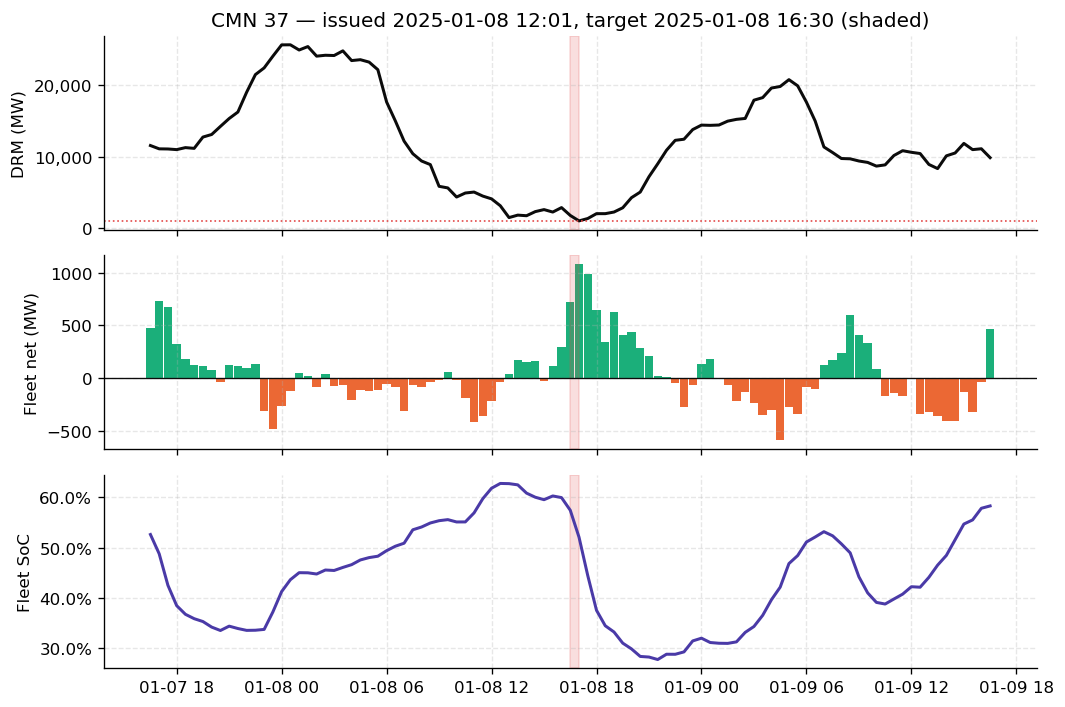

  During the notice: fleet net +720 MW (+0.17 per MW online), SoC 57%


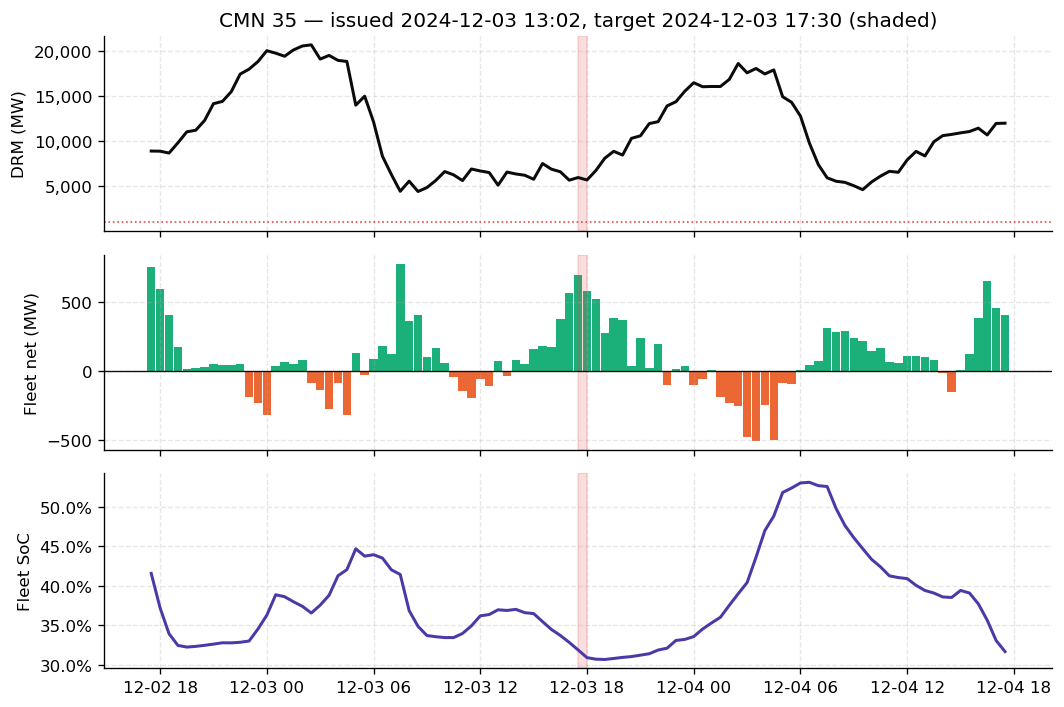

  During the notice: fleet net +699 MW (+0.18 per MW online), SoC 32%


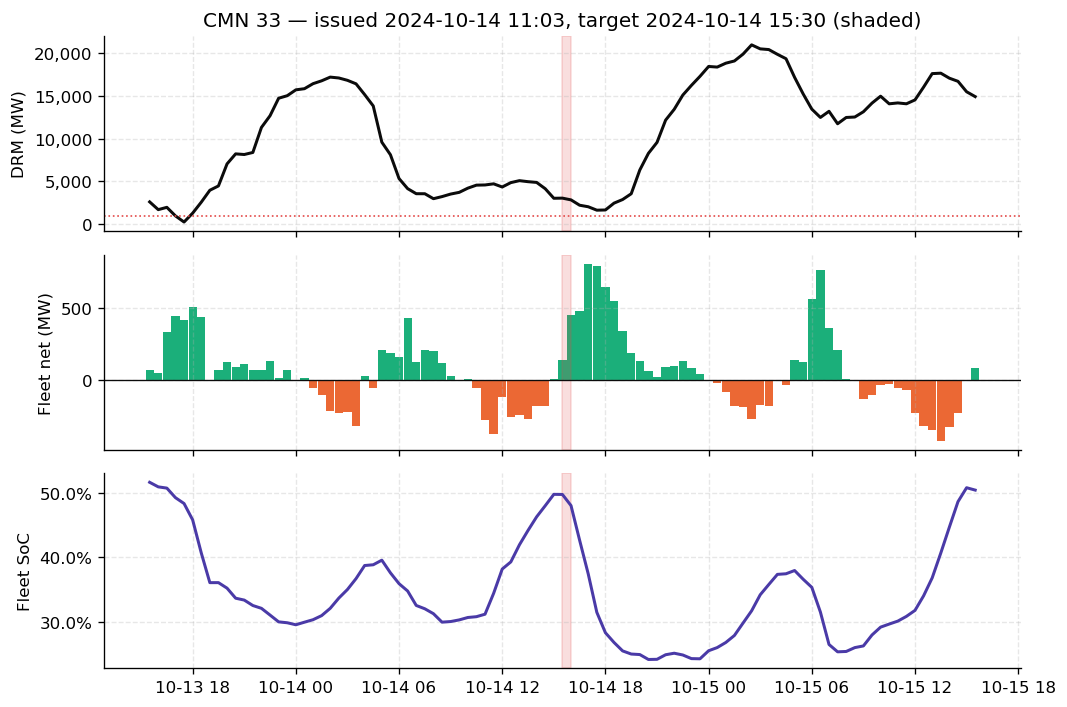

  During the notice: fleet net +139 MW (+0.04 per MW online), SoC 50%


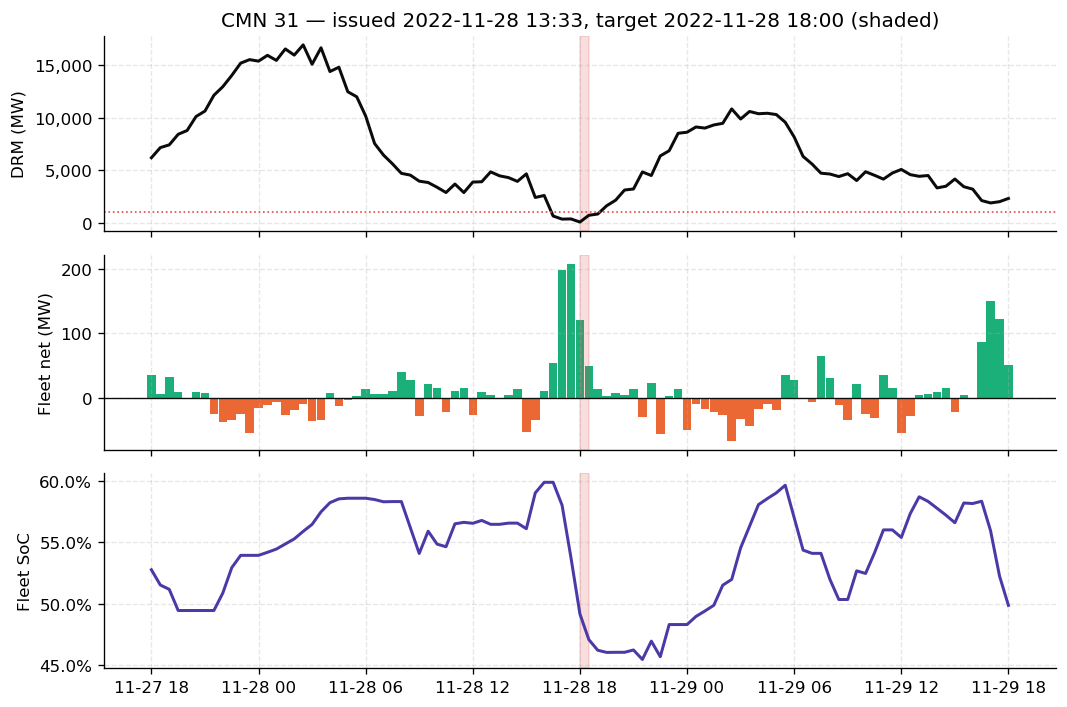

  During the notice: fleet net +121 MW (+0.11 per MW online), SoC 49%


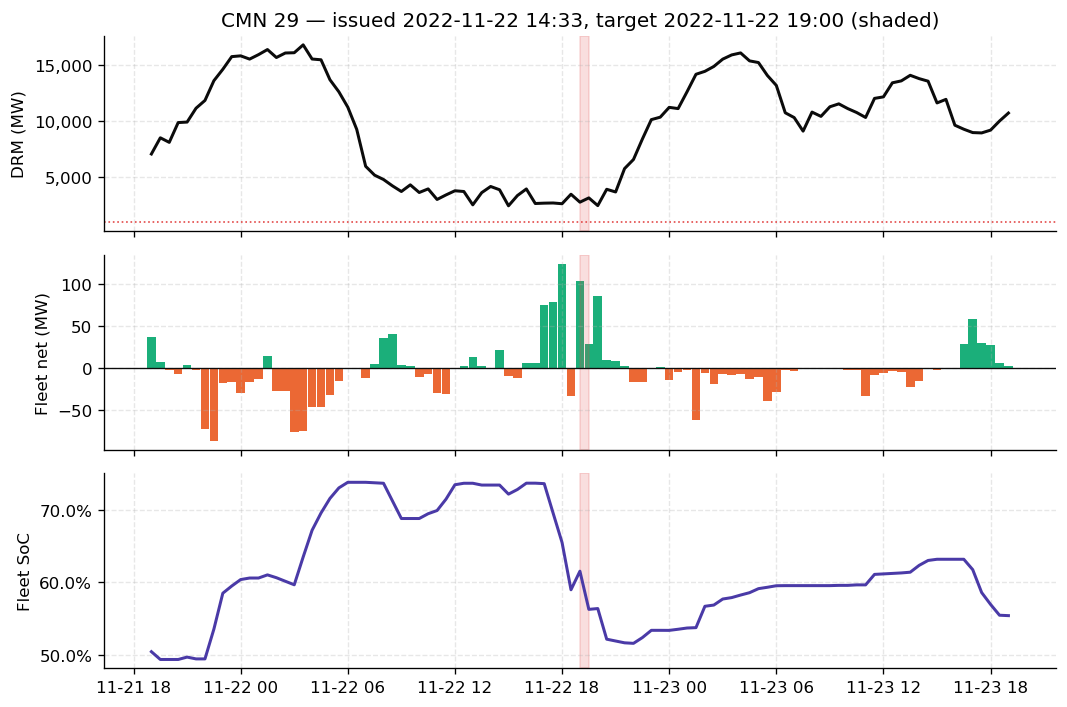

  During the notice: fleet net +103 MW (+0.10 per MW online), SoC 62%


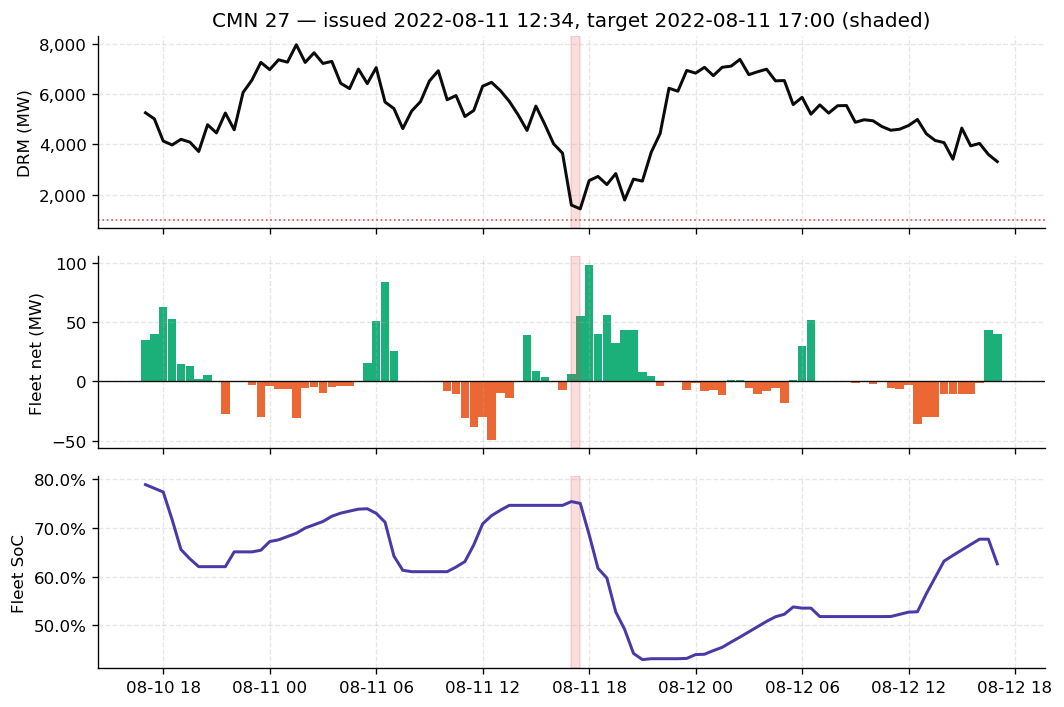

  During the notice: fleet net +6 MW (+0.01 per MW online), SoC 75%


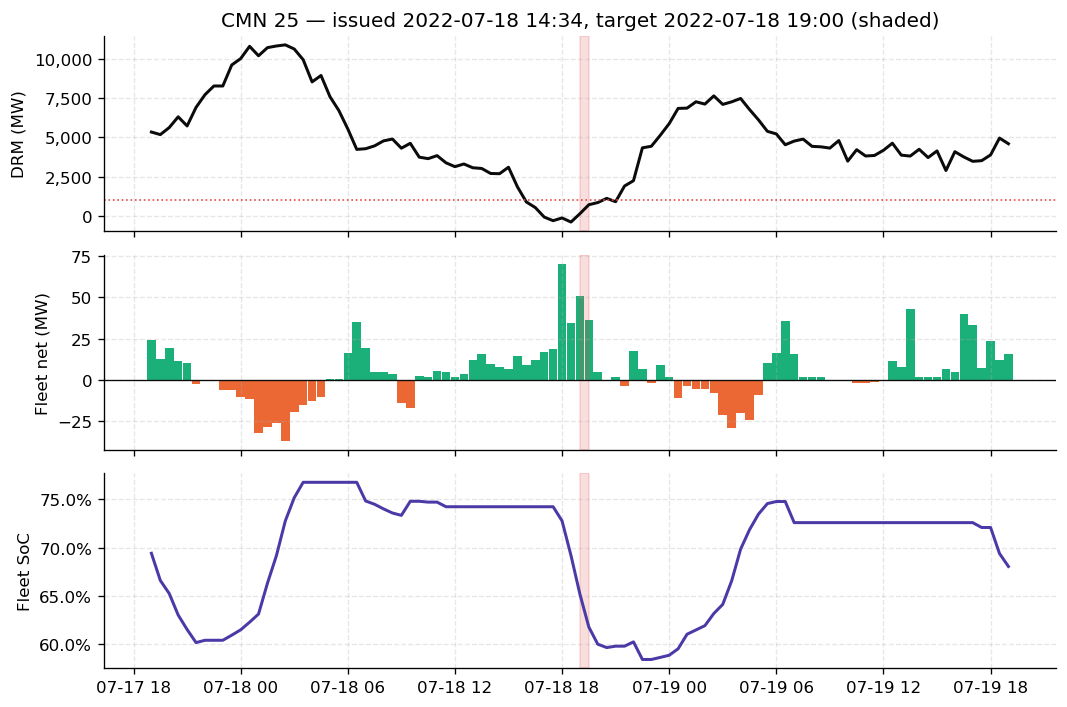

  During the notice: fleet net +51 MW (+0.07 per MW online), SoC 65%


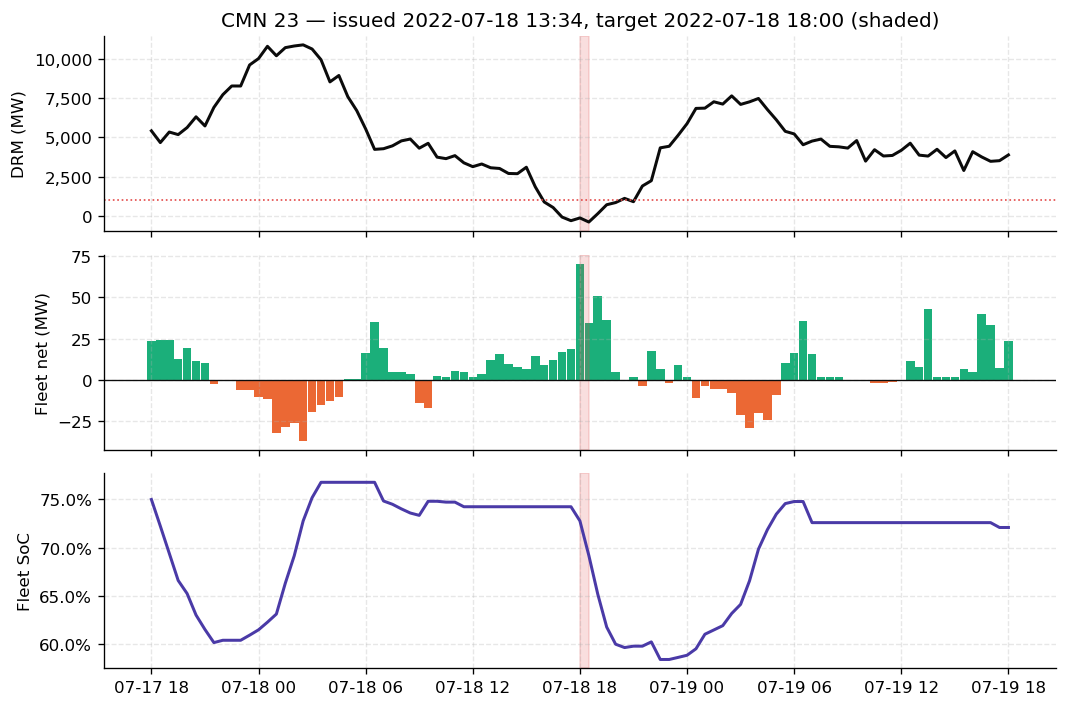

  During the notice: fleet net +70 MW (+0.09 per MW online), SoC 73%


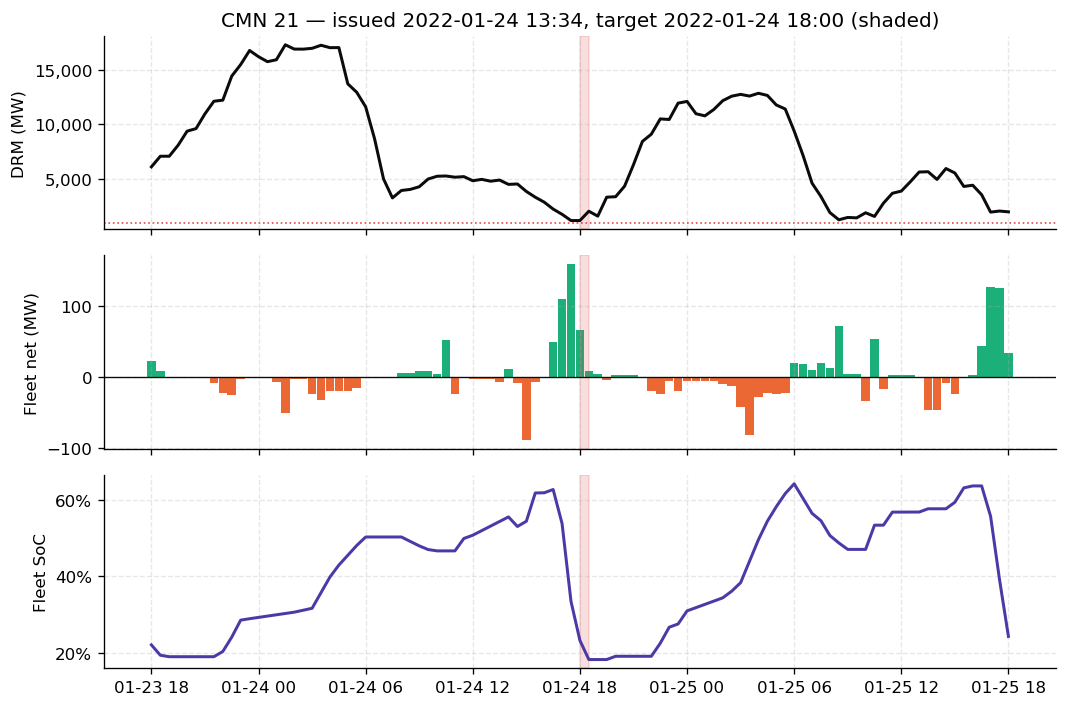

  During the notice: fleet net +66 MW (+0.12 per MW online), SoC 23%


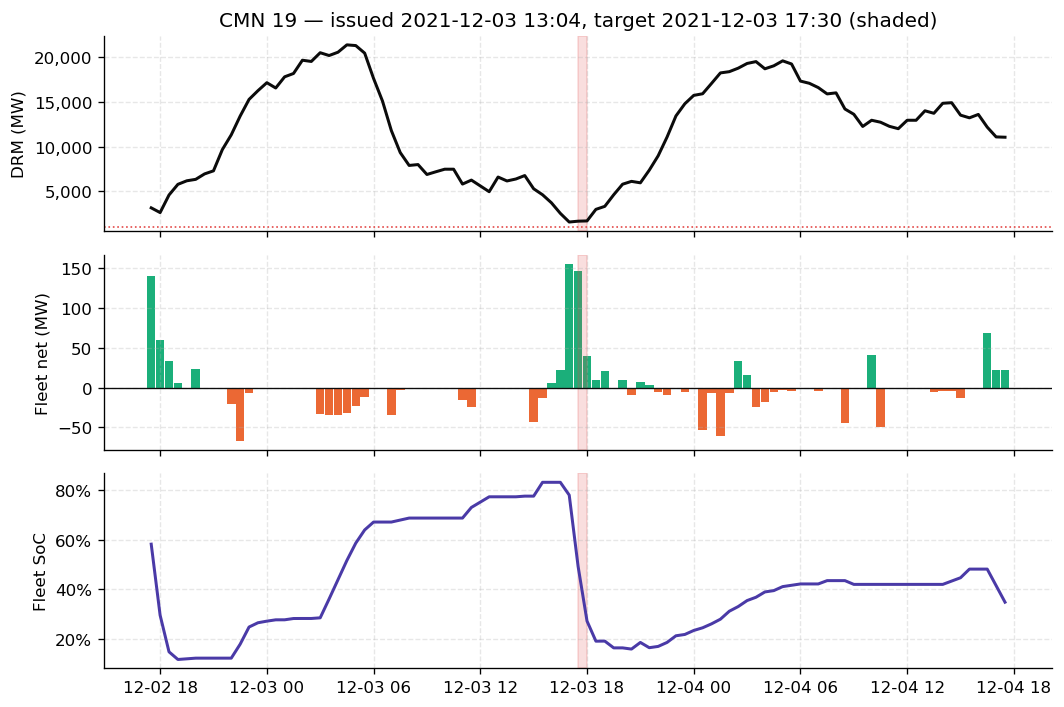

  During the notice: fleet net +146 MW (+0.34 per MW online), SoC 49%


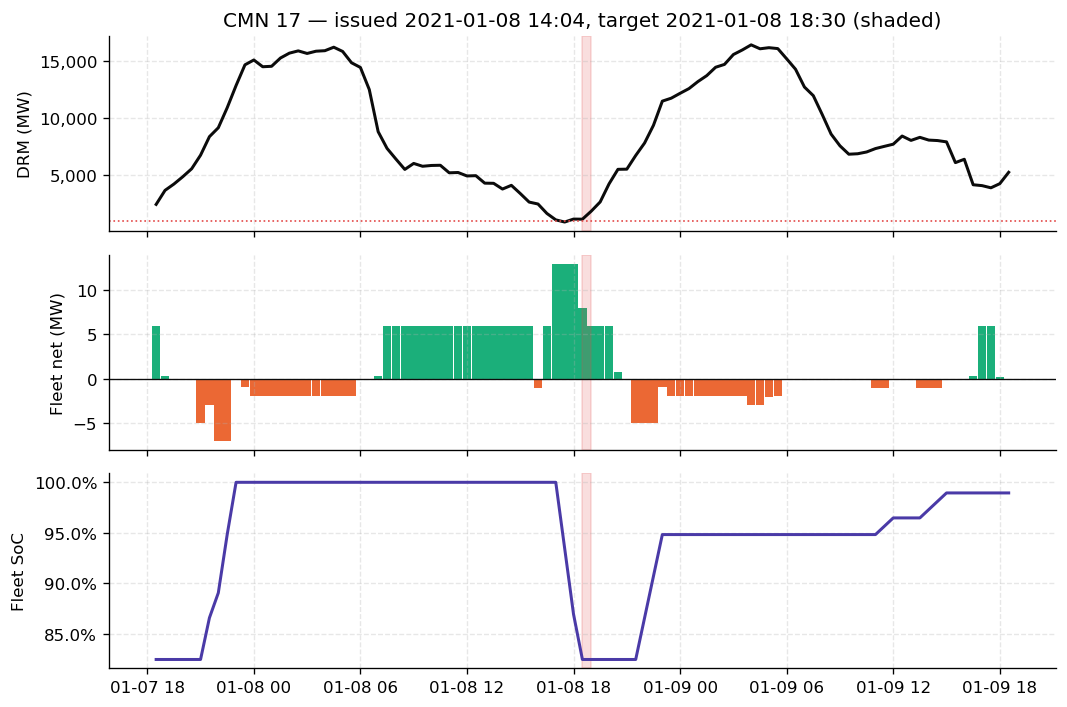

  During the notice: fleet net +8 MW (+0.02 per MW online), SoC 82%


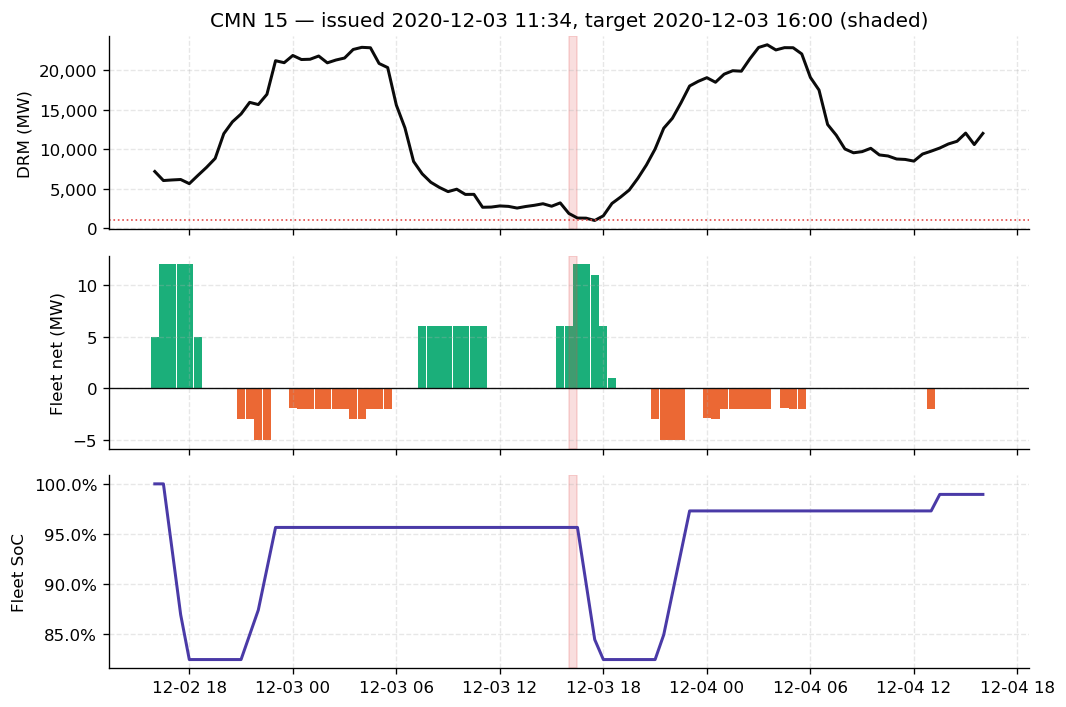

  During the notice: fleet net +6 MW (+0.02 per MW online), SoC 96%


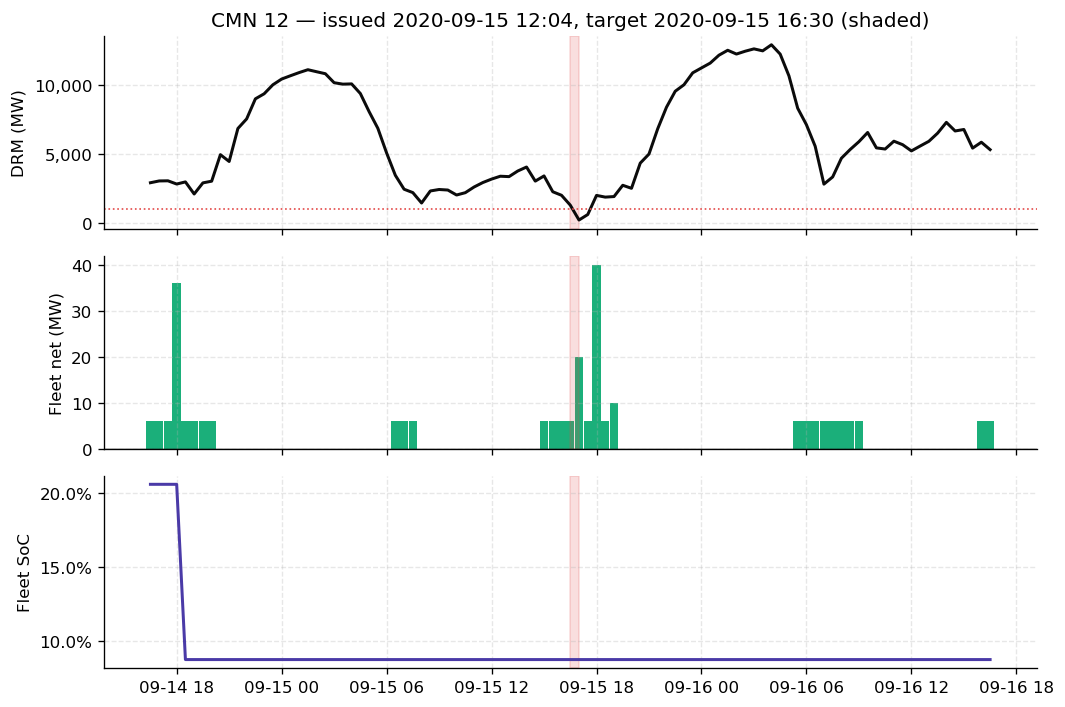

  During the notice: fleet net +6 MW (+0.02 per MW online), SoC 9%


In [11]:
# Capacity Market Notices are rare by design, so these are exhibits, not statistics.
if cmn_issued.empty:
    skip("no Capacity Market Notice in the window — nothing to exhibit")
else:
    # Pair each issued notice with the expiry covering the same target period:
    # whether a notice was still standing at delivery is the whole question.
    survived = 0
    rows = []
    for _, notice in cmn_issued.iterrows():
        match = cmn_expiry[cmn_expiry["start_utc"] == notice["start_utc"]]
        cancelled_at = match["posted_utc"].min() if not match.empty else pd.NaT
        lead_h = ((notice["start_utc"] - cancelled_at).total_seconds() / 3600
                  if pd.notna(cancelled_at) else np.nan)
        survived += int(pd.isna(cancelled_at))
        rows.append({"notice": int(notice["notice_id"]),
                     "issued": notice["posted_utc"], "target": notice["start_utc"],
                     "cancelled": cancelled_at, "cancelled_h_before_target": lead_h})
    cmn_life = pd.DataFrame(rows)
    print(f"{len(cmn_issued)} Capacity Market Notice(s) issued in the window:")
    print(cmn_life.to_string(index=False))
    print(f"\nStill standing when the targeted period arrived: {survived}/{len(cmn_issued)}."
          + ("  Every notice was withdrawn before delivery — the declared-shortfall tier "
             "records a *warning*, not a realised shortfall." if survived == 0 else ""))
    for _, notice in cmn_issued.iterrows():
        centre = notice["start_utc"]
        lo, hi = centre - pd.Timedelta(hours=24), centre + pd.Timedelta(hours=24)
        win = grid[(grid >= lo) & (grid <= hi)]
        if len(win) < 4:
            continue
        fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1, 1]})
        axes[0].plot(win, drm.reindex(win).values, color=C["ink"], lw=1.8)
        axes[0].axhline(DRM_CRITICAL_MW, color=C["cost"], ls=":", lw=1)
        axes[0].set_ylabel("DRM (MW)")
        axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
        axes[1].bar(win, fleet_net.reindex(win).values, width=0.02,
                    color=[C["discharge"] if v > 0 else C["charge"]
                           for v in fleet_net.reindex(win).fillna(0)])
        axes[1].axhline(0, color=C["ink"], lw=0.8)
        axes[1].set_ylabel("Fleet net (MW)")
        if len(USABLE_SOC):
            axes[2].plot(win, fleet_soc.reindex(win).values, color=C["soc"], lw=1.8)
            axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        axes[2].set_ylabel("Fleet SoC")
        end = notice["end_utc"] if pd.notna(notice["end_utc"]) else centre + pd.Timedelta(minutes=30)
        for ax in axes:
            ax.axvspan(centre, end, color=C["cost"], alpha=0.18)
        axes[0].set_title(f"CMN {int(notice['notice_id'])} — issued "
                          f"{notice['posted_utc']:%Y-%m-%d %H:%M}, target "
                          f"{centre:%Y-%m-%d %H:%M} (shaded)")
        plt.tight_layout()
        plt.show()

        during = grid[(grid >= centre) & (grid < end)]
        if len(during):
            print(f"  During the notice: fleet net {fleet_net.reindex(during).mean():+,.0f} MW "
                  f"({norm_net.reindex(during).mean():+.2f} per MW online)"
                  + (f", SoC {fleet_soc.reindex(during).mean():.0%}" if len(USABLE_SOC) else ""))

## 4b. Trend — is the fleet's response to tightness changing?

Section 4 answers *whether* the fleet shows up under stress. It says nothing about
**direction of travel**, and over a window in which the fleet tripled and its revenue stack
was rebuilt, that is the more useful question for anyone deciding where GB storage is headed.

Two things make a naive trend chart meaningless here, so both are controlled for.

**Seasonality.** Operator-grade scarcity is a winter phenomenon: C_LOLP periods per quarter
range from 2 to 183 across this window, so a quarterly line drawn through them would be
measuring the weather. The continuous chart therefore conditions on each quarter's **own**
tightest decile of residual load — self-normalising by construction, and n ≈ 440 every
quarter rather than single digits.

**Composition.** Active sites grow from 36 to 82 here. A rising line could simply be newer
batteries behaving differently from older ones, which is a fact about commissioning, not about
behaviour. Every series is therefore normalised per MW online *and* shown twice: once for the
full census, once for a **fixed panel** of sites present across the entire window. If the two
disagree, the trend is composition; if they agree, it is behaviour.

The operator-grade view is kept as well, as winter bars with error bars rather than a line.
Scarcity is not evenly spread across the window — some winters produce several hundred
qualifying periods and others a few dozen — so each bar carries its own n, and a bar built on
forty periods is a case study standing next to bars built on hundreds. Reading a slope across
them would mostly be reading how tight each winter happened to be.

In [12]:
def quarterly_tight_response(sites=None, decile=0.90, min_n=50):
    """Fleet response during each quarter's own tightest decile of residual load.

    Conditioning within the quarter is what makes this comparable across the
    window: "tight" always means tight *for that quarter*, so winter does not
    masquerade as a trend. Returns one row per quarter with a standard error,
    because quarters differ in length and the last one is partial.
    """
    frame = pn if sites is None else pn[pn["site"].isin(sites)]

    # Online MW is recomputed for whichever subset is passed, so the core panel
    # is normalised by its own nameplate rather than the whole fleet's.
    sub_span = frame.groupby("site")["date"].agg(first="min", last="max")
    days = pd.DatetimeIndex(sorted(frame["date"].unique()), tz="UTC")
    online = pd.Series(0.0, index=days)
    for site, row in sub_span.iterrows():
        live = (days.date >= row["first"]) & (days.date <= row["last"])
        online[live] += SITE_MW.get(site, 0.0)

    net = frame.groupby("time")["mw"].sum()
    idx = net.index
    online_here = pd.Series(online.reindex(idx.normalize()).to_numpy(), index=idx)
    frame_df = pd.DataFrame({
        "norm": net / online_here.replace(0, np.nan),
        "residual": system["residual_mw"].reindex(idx),
    }).dropna()
    # Explicit UTC: to_period would otherwise drop the timezone with a warning.
    frame_df["quarter"] = (
        frame_df.index.tz_convert("UTC").tz_localize(None).to_period("Q")
    )

    rows = []
    for quarter, group in frame_df.groupby("quarter"):
        tight = group[group["residual"] >= group["residual"].quantile(decile)]
        if len(tight) < min_n:
            continue
        rows.append({
            "quarter": str(quarter),
            "n": len(tight),
            "net": tight["norm"].mean(),
            "se": tight["norm"].std() / np.sqrt(len(tight)),
            "discharging": 100.0 * (tight["norm"] > 0).mean(),
        })
    return pd.DataFrame(rows)


trend_all = quarterly_tight_response()
trend_core = quarterly_tight_response(CORE_SITES)
trend_modern = quarterly_tight_response(MODERN_SITES)

slope = lambda t: np.polyfit(np.arange(len(t)), t["net"], 1)[0]
mw_of_panel = lambda sites: sum(SITE_MW.get(s, 0) for s in sites)

for label, frame, sites in (("Full census", trend_all, None),
                            (f"Core panel (since {WINDOW_START:%Y})", trend_core, CORE_SITES),
                            (f"Modern panel (since {MODERN_PANEL_START:%Y})", trend_modern,
                             MODERN_SITES)):
    tag = "" if sites is None else f"   [{len(sites)} sites, {mw_of_panel(sites):,.0f} MW]"
    print(f"{label:28s} {frame['net'].iloc[0]:.3f} → {frame['net'].iloc[-1]:.3f} MW/MW"
          f"   ({slope(frame) * 4:+.3f}/yr){tag}")

print("\nThe two panels do not say the same thing, and the gap is the finding. Sites fixed "
      "\nsince 2023 improve on their own account, so the rise is not only new entrants. Sites "
      "\nfixed since 2018 stay flat, so the oldest cohort did not join in — though three sites "
      "\nis a case study, not a population, and the full-window control is weak by "
      "\nconstruction: a long window can only hold a panel of whatever survived it.\n")
trend_all[["quarter", "n", "net", "se", "discharging"]].round(3)

Full census                  0.034 → 0.139 MW/MW   (+0.012/yr)
Core panel (since 2018)      0.034 → 0.022 MW/MW   (+0.000/yr)   [3 sites, 90 MW]
Modern panel (since 2023)    0.034 → 0.153 MW/MW   (+0.015/yr)   [37 sites, 1,807 MW]

The two panels do not say the same thing, and the gap is the finding. Sites fixed 
since 2023 improve on their own account, so the rise is not only new entrants. Sites 
fixed since 2018 stay flat, so the oldest cohort did not join in — though three sites 
is a case study, not a population, and the full-window control is weak by 
construction: a long window can only hold a panel of whatever survived it.



,quarter,n,net,se,discharging
0,2018Q1,432,0.034,0.002,48.843
1,2018Q2,437,0.010,0.001,15.561
2,2018Q3,442,0.016,0.001,26.923
3,2018Q4,426,0.012,0.003,42.254
4,2019Q1,404,0.043,0.005,43.812
5,2019Q2,436,0.003,0.001,32.798
6,2019Q3,432,0.007,0.001,40.278
7,2019Q4,442,0.032,0.004,42.081
8,2020Q1,434,0.022,0.003,30.184
9,2020Q2,437,0.009,0.001,28.146


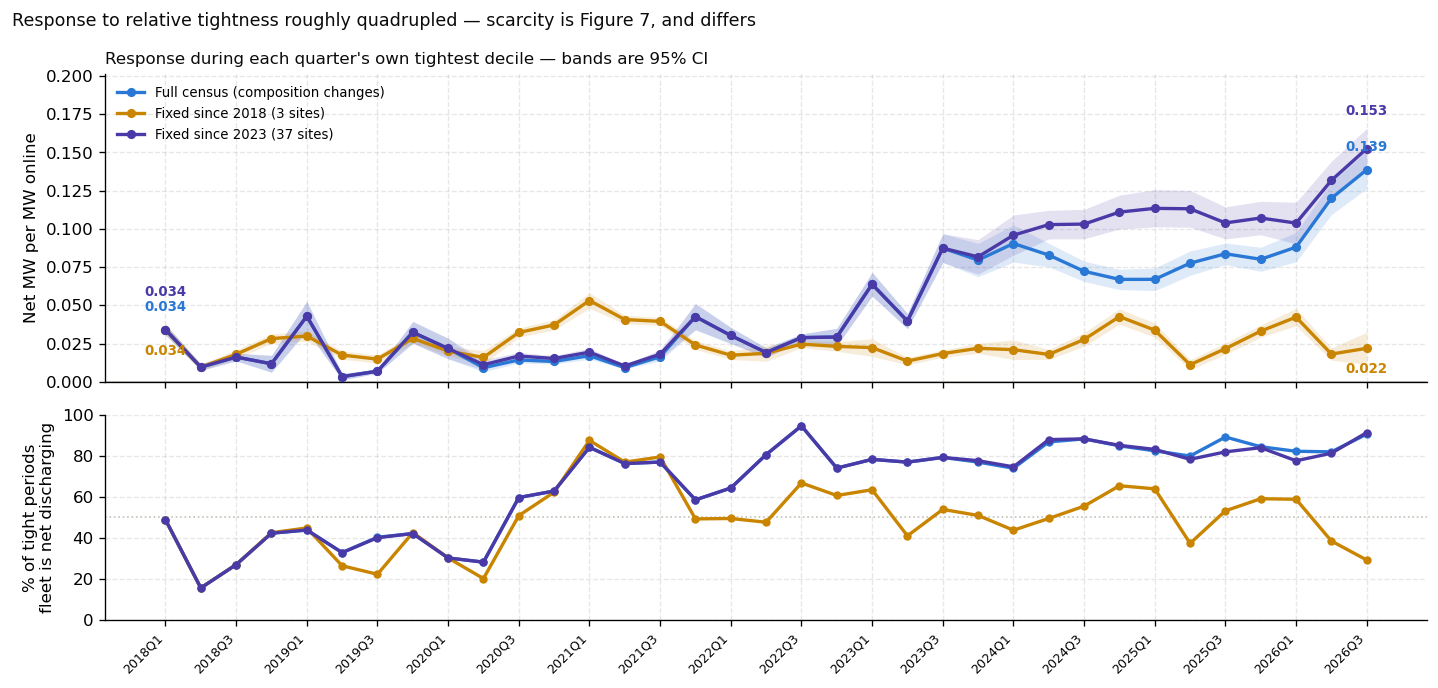

Final quarter is partial (n=264 vs ~432 typical), so read its level, not its slope.


In [13]:
# Figure 6 — direction of travel, with composition held constant as a control.
fig, axes = plt.subplots(2, 1, figsize=(12, 5.8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})
x = np.arange(len(trend_all))

ax = axes[0]
series = (
    (trend_all, C["da"], "Full census (composition changes)"),
    (trend_core, C["mid"], f"Fixed since {WINDOW_START:%Y} ({len(CORE_SITES)} sites)"),
    (trend_modern, C["soc"], f"Fixed since {MODERN_PANEL_START:%Y} ({len(MODERN_SITES)} sites)"),
)
for frame, colour, label in series:
    ax.plot(x, frame["net"], color=colour, lw=2, marker="o", ms=4.5, label=label, zorder=3)
    ax.fill_between(x, frame["net"] - 1.96 * frame["se"], frame["net"] + 1.96 * frame["se"],
                    color=colour, alpha=0.15, lw=0, zorder=2)
ax.axhline(0, color=C["ghost"], lw=1, zorder=1)
# Label the endpoints only — a number on every point would bury the shape.
# Offsets alternate so the two series' endpoint labels cannot sit on top of
# each other where the lines converge.
for (frame, colour, _), dy in zip(series, (11, -15, 20)):
    for i in (0, len(frame) - 1):
        ax.annotate(f"{frame['net'].iloc[i]:.3f}", (x[i], frame["net"].iloc[i]),
                    xytext=(0, dy), textcoords="offset points", ha="center",
                    fontsize=8, color=colour, fontweight="bold")
ax.set_ylabel("Net MW per MW online")
ax.set_ylim(0, max(f["net"].max() for f, _, _ in series) * 1.32)
ax.set_title("Response during each quarter's own tightest decile — bands are 95% CI",
             fontsize=10, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=8, loc="upper left", ncol=1)

ax = axes[1]
for frame, colour, _ in series:
    ax.plot(np.arange(len(frame)), frame["discharging"], color=colour, lw=2,
            marker="o", ms=4, zorder=3)
ax.set_ylim(0, 100)
ax.set_ylabel("% of tight periods\nfleet is net discharging")
# Eight winters is ~34 quarters: label every other one so they stay readable.
ax.set_xticks(x[::2], trend_all["quarter"][::2], rotation=45, ha="right", fontsize=7.5)
ax.axhline(50, color=C["ghost"], lw=1, ls=":", zorder=1)

fig.suptitle("Response to relative tightness roughly quadrupled — scarcity is Figure 7, and differs",
             fontsize=10.5, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
plt.show()

print(f"Final quarter is partial (n={int(trend_all['n'].iloc[-1])} vs ~{int(trend_all['n'].iloc[:-1].mean())} "
      f"typical), so read its level, not its slope.")

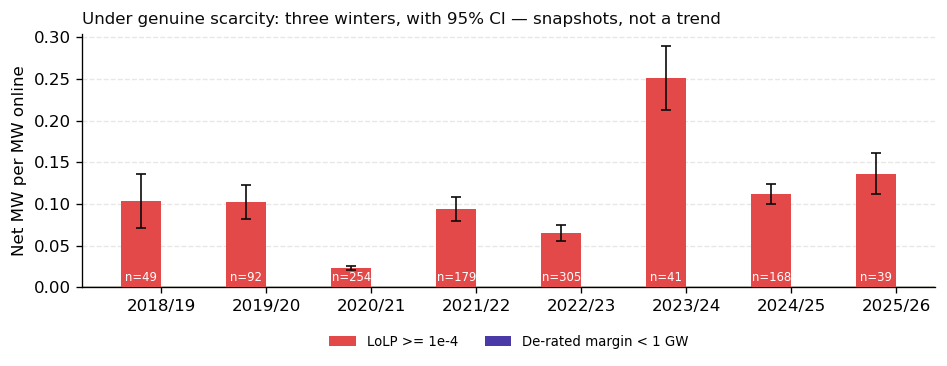

'     measure  winter   n   net    se\nLoLP >= 1e-4 2018/19  49 0.103 0.017\nLoLP >= 1e-4 2019/20  92 0.102 0.011\nLoLP >= 1e-4 2020/21 254 0.023 0.001\nLoLP >= 1e-4 2021/22 179 0.094 0.007\nLoLP >= 1e-4 2022/23 305 0.065 0.005\nLoLP >= 1e-4 2023/24  41 0.251 0.019\nLoLP >= 1e-4 2024/25 168 0.111 0.006\nLoLP >= 1e-4 2025/26  39 0.136 0.013'

In [14]:
# Figure 7 — the operator-grade view: three winters, not a trend line.
winter_of = lambda idx: np.where(idx.month >= 10, idx.year,
                                 np.where(idx.month <= 3, idx.year - 1, np.nan))

winter = pd.Series(winter_of(grid), index=grid)
rows = []
for label, mask in (("LoLP >= 1e-4", C_LOLP),):
    m = mask.fillna(False)
    for yr, grp in norm_net[m].groupby(winter[m]):
        if pd.isna(yr) or len(grp) < 20:
            continue
        rows.append({"measure": label, "winter": f"{int(yr)}/{str(int(yr) + 1)[2:]}",
                     "n": len(grp), "net": grp.mean(),
                     "se": grp.std() / np.sqrt(len(grp))})
winters = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 3.2))
labels = sorted(winters["winter"].unique())
xw = np.arange(len(labels))
width = 0.38
for k, (measure, colour) in enumerate((("LoLP >= 1e-4", C["cost"]),
                                       ("De-rated margin < 1 GW", C["soc"]))):
    sub = winters[winters["measure"] == measure].set_index("winter").reindex(labels)
    ax.bar(xw + (k - 0.5) * width, sub["net"], width=width, color=colour, label=measure,
           yerr=1.96 * sub["se"], capsize=3,
           error_kw={"lw": 1, "ecolor": C["ink"]}, zorder=3)
    for i, (v, n) in enumerate(zip(sub["net"], sub["n"])):
        if pd.notna(v):
            ax.annotate(f"n={int(n)}", (xw[i] + (k - 0.5) * width, 0), xytext=(0, 4),
                        textcoords="offset points", ha="center", fontsize=7, color="white")

ax.set_xticks(xw, labels)
ax.set_ylabel("Net MW per MW online")
ax.axhline(0, color=C["ghost"], lw=1)
ax.grid(axis="x", visible=False)
ax.set_title("Under genuine scarcity: three winters, with 95% CI — snapshots, not a trend",
             fontsize=10, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper center",
          bbox_to_anchor=(0.5, -0.14))
plt.tight_layout()
plt.show()

winters.round(3).to_string(index=False)

**The rise is real, and it is not the same fleet getting better.**

Conditioned on *relative* tightness the fleet's response roughly quadruples across the window,
from 0.034 MW per MW online in 2018Q1 to 0.132 in 2026Q3. Sites held fixed since 2023 improve
on their own account over that stretch (0.087 → 0.144), so this is not merely new entrants
diluting old ones. But the handful of sites present since 2018 stay flat near 0.02 throughout —
the oldest cohort did not participate in the improvement. Three sites is a case study rather
than a population, and a long window can only hold a panel of whatever survived it, so that
divergence is a lead worth following rather than a conclusion. What it does rule out is the
simplest story: "the same batteries respond more than they used to" is not what the data says.

**Under genuine scarcity there is no trend at all — there is an energy constraint.** The winter
series runs 0.127, 0.106, 0.023, 0.102, 0.070, 0.118, 0.151 MW/MW, which looks like noise until
it is placed against how much scarcity each winter contained. Then it is not noise: the
correlation between a winter's count of qualifying periods and the fleet's average response to
them is **−0.85**. The winters that demanded most got least. 2020/21 produced 212 qualifying
periods and drew 0.023 MW/MW; 2025/26 produced 25 and drew 0.151.

That is exactly what duration-limited assets should look like. A one- to two-hour battery
cannot be near full for every event in a winter that keeps producing them, so response per
event falls as events multiply. The fleet is not less willing in a hard winter; it is emptier.

**Which figure answers which question.** Whether GB batteries are becoming more useful to the
system in general: the quarterly series, and the answer is yes. Whether they can be relied on
when the system is genuinely short: the winter bars, and the answer is that it depends mostly
on how short, and how often — a mild winter flatters them and a hard one exhausts them. Quoting
the rising line as evidence of scarcity reliability would be quoting the wrong figure.

**Mechanism is not established.** The step around 2026Q2 coincides with the rebuilding of GB's
response and reserve markets, and the whole window spans the rise and collapse of Dynamic
Containment. A battery discharging into tightness because the spread finally pays for it is
indistinguishable here from one doing so for any other reason.

## 5. RQ2 — Stress modification: does the fleet relieve or deepen tight margins?

The sharpest version of the question: when the de-rated margin is critically thin, is the
battery fleet a **supplier** or a **load**? Every half-hour the fleet spends charging while
the margin is under 1 GW is a half-hour it is subtracting from the very margin the system is
short of — "cannibalistic" charging.

Fleet net MW is also expressed as a share of the margin itself, which is the number that says
whether the fleet's behaviour is material to the tightness or merely coincident with it.

RQ2 — fleet behaviour by de-rated-margin band
               n  mean_net_MW  mean_MW_per_MW  charging_share  net_pct_of_DRM
band                                                                         
<1,000      34.0       56.326           0.055           0.029           0.016
1–2k       226.0       69.378           0.066           0.035           0.008
2–4k      2801.0       49.250           0.043           0.105           0.002
4–7k     14008.0       41.732           0.022           0.213           0.000
>7k     132243.0        4.827           0.000           0.371           0.000

Tightest band (<1,000 MW, n=34, distribution): fleet net +56 MW, charging in 3% of periods, median contribution +1.6% of the margin itself.

Tightest DRM decile (n=14,932, DRM ≤ 6,673 MW): fleet net +44 MW, charging in 19% of periods.


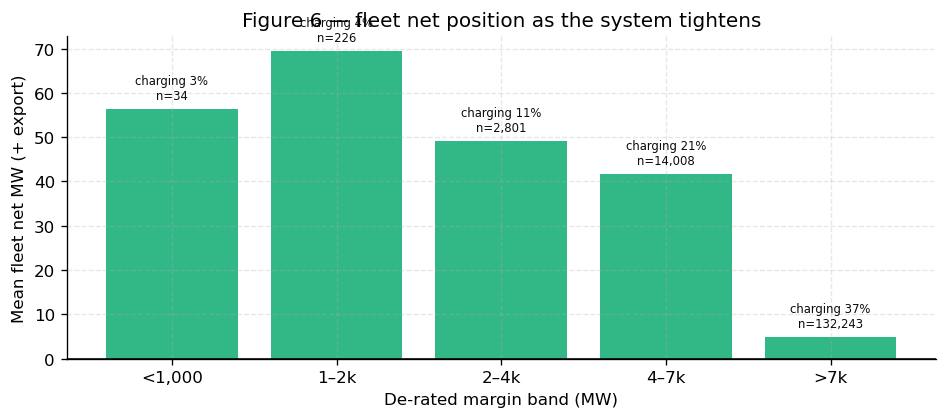

In [15]:
band_df = pd.DataFrame({"drm": drm, "net": fleet_net, "norm": norm_net,
                        "avail": avail_factor}).dropna(subset=["drm", "net"])
if band_df.empty:
    skip("no period has both a DRM print and fleet PN data")
    rq2 = pd.DataFrame()
else:
    band_df["band"] = pd.cut(band_df["drm"], DRM_BANDS, labels=DRM_BAND_LABELS, right=False)
    rq2 = band_df.groupby("band", observed=False).apply(
        lambda g: pd.Series({
            "n": len(g),
            "mean_net_MW": g["net"].mean(),
            "mean_MW_per_MW": g["norm"].mean(),
            "charging_share": (g["net"] < 0).mean(),
            "net_pct_of_DRM": (g["net"] / g["drm"]).median(),
        }), include_groups=False)
    print("RQ2 — fleet behaviour by de-rated-margin band")
    print(rq2.round(3).to_string())

    tight_band = rq2.iloc[0]
    if tight_band["n"] == 0:
        skip("no period with DRM < 1,000 MW — the tightest band is empty in this window")
    else:
        kind = "case study" if tight_band["n"] < MIN_N_DIST else "distribution"
        print(f"\nTightest band (<1,000 MW, n={int(tight_band['n'])}, {kind}): fleet net "
              f"{tight_band['mean_net_MW']:+,.0f} MW, charging in "
              f"{tight_band['charging_share']:.0%} of periods, median contribution "
              f"{tight_band['net_pct_of_DRM']:+.1%} of the margin itself.")
        if tight_band["n"] < MIN_N_DIST:
            print("  Sub-1GW margins are near-unheard-of in GB: read the band above as an "
                  "anecdote and the threshold sets as the evidence.")
        band_df["decile"] = pd.qcut(band_df["drm"], 10, labels=False, duplicates="drop")
        tightest_decile = band_df[band_df["decile"] == 0]
        print(f"\nTightest DRM decile (n={len(tightest_decile):,}, DRM ≤ "
              f"{tightest_decile['drm'].max():,.0f} MW): fleet net "
              f"{tightest_decile['net'].mean():+,.0f} MW, charging in "
              f"{(tightest_decile['net'] < 0).mean():.0%} of periods.")

    plot = rq2[rq2["n"] > 0]
    if len(plot):
        fig, ax = plt.subplots(figsize=(8, 3.6))
        colours = [C["discharge"] if v >= 0 else C["charge"] for v in plot["mean_net_MW"]]
        bars = ax.bar(range(len(plot)), plot["mean_net_MW"].values, color=colours, alpha=0.9)
        for i, (_, row) in enumerate(plot.iterrows()):
            ax.annotate(f"charging {row['charging_share']:.0%}\nn={int(row['n']):,}",
                        (i, row["mean_net_MW"]), textcoords="offset points",
                        xytext=(0, 6 if row["mean_net_MW"] >= 0 else -22),
                        ha="center", fontsize=7, color=C["ink"])
        ax.axhline(0, color=C["ink"], lw=1)
        ax.set_xticks(range(len(plot)))
        ax.set_xticklabels(plot.index.astype(str))
        ax.set_xlabel("De-rated margin band (MW)")
        ax.set_ylabel("Mean fleet net MW (+ export)")
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
        ax.set_title("Figure 6 — fleet net position as the system tightens")
        plt.tight_layout()
        plt.show()

## 6. RQ3 — Dynamic foresight: does the fleet see it coming?

Elexon publishes each settlement period's loss-of-load probability and de-rated margin five
times, at roughly 12, 8, 4, 2 and 1 hours ahead. That gives two separable questions:

1. **Was the tightness visible in advance?** The earliest horizon whose print already crossed
   the critical threshold is the hours of warning the market had.
2. **Did behaviour change once it was visible?** State of charge and dispatch running into a
   critical period, against matched control periods (same half-hour of day, same month **and
   the same year**, on days with no critical period at all).

   The year matters more than it looks. Matching on clock position alone let a 2018 evening
   stand in for a 2026 one, and the fleet's mean state of charge rose across the window as it
   grew — so the comparison credited the fleet with arriving **6.5 points fuller** than usual
   before a critical period. Adding the year reverses it to **1.3 points emptier**, and the two
   state-of-charge inference schemes, which had contradicted each other on the sign, now agree.
   The anticipation was an artefact of comparing across eras.

**Read this as association, not reaction.** Elexon serves only the *final* Physical
Notification for a period — the revision history that would show an operator re-planning is
not published — so what follows compares realised dispatch, and cannot prove the forecast
caused it.

Critical periods with prints: 2076
Visible at some horizon      : 2076 (100%)
Median warning               : 12 h ahead

Earliest horizon that already crossed the threshold:
warning_h
12    1972
8       44
4       34
2       10
1       16


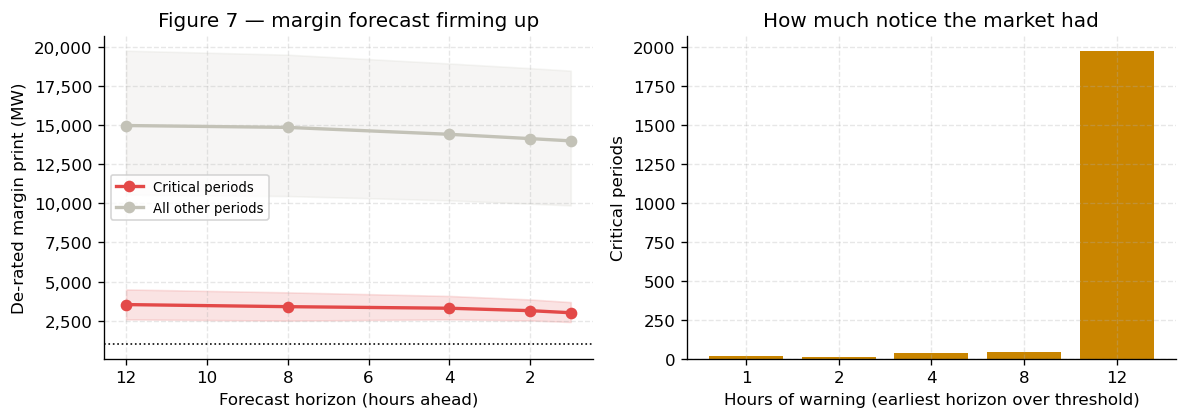

In [16]:
h_drm = prints.pivot_table(index="time", columns="horizon", values="drm_mw", aggfunc="last")
h_lolp = prints.pivot_table(index="time", columns="horizon", values="lolp", aggfunc="last")
HORIZONS = sorted([h for h in h_drm.columns], reverse=True)

crit_times = grid[CRITICAL]
if len(crit_times) == 0:
    skip("no critical period in this window — foresight analysis unavailable")
    warning_h = pd.Series(dtype=float)
else:
    rows = []
    for t in crit_times:
        if t not in h_drm.index:
            continue
        earliest = np.nan
        for h in HORIZONS:
            d = h_drm.at[t, h] if h in h_drm.columns else np.nan
            l = h_lolp.at[t, h] if h in h_lolp.columns else np.nan
            if (pd.notna(d) and d < DRM_CRITICAL_MW) or (pd.notna(l) and l > 0):
                earliest = h
                break
        rows.append({"time": t, "warning_h": earliest})
    warning_h = pd.DataFrame(rows).set_index("time")["warning_h"]
    seen = warning_h.dropna()
    print(f"Critical periods with prints: {len(warning_h)}")
    print(f"Visible at some horizon      : {len(seen)} ({len(seen) / max(len(warning_h), 1):.0%})")
    if len(seen):
        print(f"Median warning               : {seen.median():.0f} h ahead")
        print("\nEarliest horizon that already crossed the threshold:")
        print(seen.value_counts().sort_index(ascending=False).rename("periods").to_string())

    # Figure 7 — how the margin forecast for a critical period firms up.
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    ax = axes[0]
    crit_idx = [t for t in crit_times if t in h_drm.index]
    calm_idx = [t for t in h_drm.index if t not in set(crit_times)]
    for label, idx, colour in (("Critical periods", crit_idx, C["cost"]),
                               ("All other periods", calm_idx, C["ghost"])):
        if not idx:
            continue
        med = h_drm.loc[idx, HORIZONS].median()
        q1 = h_drm.loc[idx, HORIZONS].quantile(0.25)
        q3 = h_drm.loc[idx, HORIZONS].quantile(0.75)
        ax.plot(HORIZONS, med.values, color=colour, lw=2, marker="o", label=label)
        ax.fill_between(HORIZONS, q1.values, q3.values, color=colour, alpha=0.15)
    ax.axhline(DRM_CRITICAL_MW, color=C["ink"], ls=":", lw=1)
    ax.invert_xaxis()
    ax.set_xlabel("Forecast horizon (hours ahead)")
    ax.set_ylabel("De-rated margin print (MW)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.legend(fontsize=8)
    ax.set_title("Figure 7 — margin forecast firming up")

    ax = axes[1]
    if len(seen):
        counts = seen.value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color=C["mid"])
        ax.set_xlabel("Hours of warning (earliest horizon over threshold)")
        ax.set_ylabel("Critical periods")
        ax.set_title("How much notice the market had")
    else:
        ax.text(0.5, 0.5, "No critical period crossed the threshold in advance",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

Critical onsets: 515 | matched control anchors: 2575


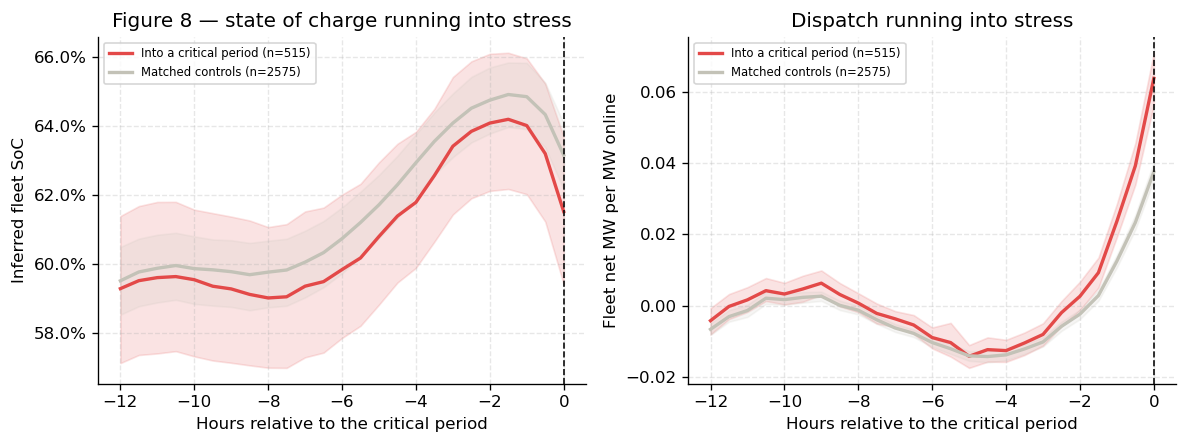

SoC at the critical period : 61.5% vs 63.2% in controls (-1.6%)
SoC 6 h earlier            : 59.8% vs 60.7%


Sensitivity (re-anchored)  : 51.5% vs 53.4% (-1.9%); schemes agree on sign (primary -1.6%)


In [17]:
# Controls are matched on year as well as clock position.
#
# Matching on (month, hour, minute) alone would let a January 2018 half-hour
# stand in for a January 2026 one. Those are different systems, not different
# moments: the fleet roughly doubled across this window and the margin loosened
# with it, so an "ordinary evening" in 2018 is not the counterfactual for an
# ordinary evening in 2026. Adding the year costs nothing here — the tightest
# onset bucket still holds 10 candidates and the median 21, so every onset
# keeps its full complement of controls.
crit_days = set(pd.DatetimeIndex(grid[CRITICAL]).date)
control_pool = {}
for ts in grid:
    if ts.date() in crit_days:
        continue
    control_pool.setdefault((ts.year, ts.month, ts.hour, ts.minute), []).append(ts)

onsets = grid[CRITICAL & ~pd.Series(CRITICAL, index=grid).shift(1, fill_value=False).values]
rng = np.random.default_rng(7)


def matched_controls(t0, k=MAX_CONTROLS):
    pool = control_pool.get((t0.year, t0.month, t0.hour, t0.minute), [])
    if not pool:
        return []
    take = min(k, len(pool))
    return list(rng.choice(np.array(pool, dtype=object), size=take, replace=False))


def trajectory(series, anchors, back=LOOKBACK_HH, fwd=0):
    '''Mean profile of ``series`` at half-hour offsets around each anchor.'''
    offsets = range(-back, fwd + 1)
    rows = []
    for a in anchors:
        rows.append([series.get(a + pd.Timedelta(minutes=30 * o), np.nan) for o in offsets])
    arr = np.array(rows, dtype=float)
    return pd.DataFrame(arr, columns=[o * 0.5 for o in offsets])


def boot_ci(frame, n=400):
    '''Percentile bootstrap CI of the column means, over events.'''
    if len(frame) < 3:
        return None, None
    with warnings.catch_warnings():
        # A resample can draw only all-NaN rows for an offset; nanmean warns
        # and returns NaN, which is the answer we want anyway.
        warnings.simplefilter("ignore", RuntimeWarning)
        means = np.array([np.nanmean(frame.sample(len(frame), replace=True).values, axis=0)
                          for _ in range(n)])
        return np.nanpercentile(means, 2.5, axis=0), np.nanpercentile(means, 97.5, axis=0)


if len(onsets) == 0 or not len(USABLE_SOC):
    skip("no critical onset or no SoC-usable site — run-up analysis unavailable")
else:
    ctrl_anchors = [c for t0 in onsets for c in matched_controls(t0)]
    ev_soc = trajectory(fleet_soc, onsets)
    ct_soc = trajectory(fleet_soc, ctrl_anchors)
    ev_net = trajectory(norm_net, onsets)
    ct_net = trajectory(norm_net, ctrl_anchors)
    print(f"Critical onsets: {len(onsets)} | matched control anchors: {len(ctrl_anchors)}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
    for ax, ev, ct, label, fmt in (
        (axes[0], ev_soc, ct_soc, "Inferred fleet SoC", mticker.PercentFormatter(1.0)),
        (axes[1], ev_net, ct_net, "Fleet net MW per MW online", None),
    ):
        x = ev.columns.astype(float)
        for frame, colour, name in ((ev, C["cost"], f"Into a critical period (n={len(ev)})"),
                                    (ct, C["ghost"], f"Matched controls (n={len(ct)})")):
            if not len(frame):
                continue
            mean = np.nanmean(frame.values, axis=0)
            ax.plot(x, mean, color=colour, lw=2, label=name)
            lo, hi = boot_ci(frame)
            if lo is not None:
                ax.fill_between(x, lo, hi, color=colour, alpha=0.15)
        ax.axvline(0, color=C["ink"], lw=1, ls="--")
        ax.set_xlabel("Hours relative to the critical period")
        ax.set_ylabel(label)
        if fmt:
            ax.yaxis.set_major_formatter(fmt)
        ax.legend(fontsize=7)
    axes[0].set_title("Figure 8 — state of charge running into stress")
    axes[1].set_title("Dispatch running into stress")
    plt.tight_layout()
    plt.show()

    at_zero_ev, at_zero_ct = np.nanmean(ev_soc[0.0]), np.nanmean(ct_soc[0.0])
    print(f"SoC at the critical period : {at_zero_ev:.1%} vs {at_zero_ct:.1%} in controls "
          f"({at_zero_ev - at_zero_ct:+.1%})")
    print(f"SoC 6 h earlier            : {np.nanmean(ev_soc[-6.0]):.1%} vs "
          f"{np.nanmean(ct_soc[-6.0]):.1%}")

    # Robustness: the same comparison under the daily-re-anchored SoC scheme.
    ev_a = trajectory(fleet_soc_anchor, onsets)
    ct_a = trajectory(fleet_soc_anchor, ctrl_anchors)
    d_primary = np.nanmean(ev_soc[0.0]) - np.nanmean(ct_soc[0.0])
    d_anchor = np.nanmean(ev_a[0.0]) - np.nanmean(ct_a[0.0])
    agree = "agree" if np.sign(d_primary) == np.sign(d_anchor) else "DISAGREE"
    print(f"Sensitivity (re-anchored)  : {np.nanmean(ev_a[0.0]):.1%} vs "
          f"{np.nanmean(ct_a[0.0]):.1%} ({d_anchor:+.1%}); schemes {agree} on sign "
          f"(primary {d_primary:+.1%})")

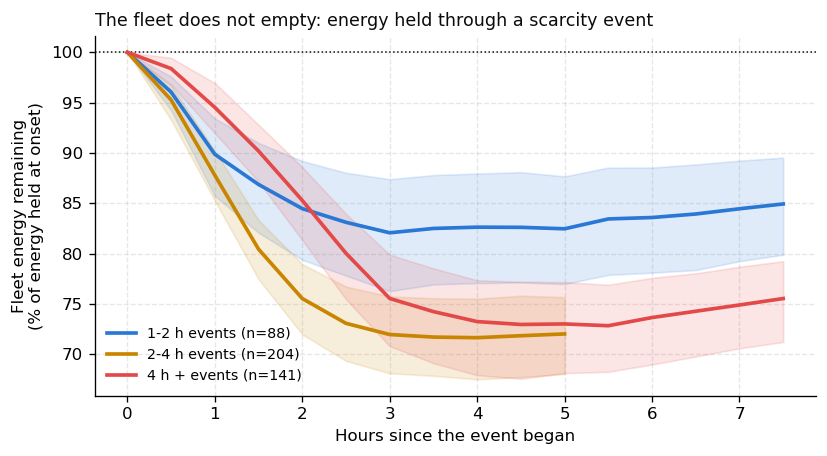

1-2 h    n= 88  energy remaining: 2 h 84% | 4 h 83%
2-4 h    n=204  energy remaining: 2 h 76% | 4 h 72%
4 h +    n=141  energy remaining: 2 h 85% | 4 h 73%


In [18]:
# Figure — depletion through an event: does the fleet run out before the
# system lets go? The counterfactual battery does, at its 10% floor by 21:00.
# This asks the same question of the observed fleet, per event rather than on
# an average day, and splits by how long the event actually lasted.
SURV_HH = 16                       # follow 8 hours past onset
DUR_BANDS = [(1.0, 2.0, "1-2 h"), (2.0, 4.0, "2-4 h"), (4.0, 99.0, "4 h +")]

surv = {}
for lo, hi, name in DUR_BANDS:
    sel = events_df[(events_df["hours"] >= lo) & (events_df["hours"] < hi)]
    paths = []
    for t0 in sel["start"]:
        idx = pd.date_range(t0, periods=SURV_HH, freq="30min", tz="UTC")
        p = fleet_soc.reindex(idx)
        if p.notna().sum() < 4 or not p.notna().iloc[0]:
            continue
        # Share of the energy the fleet had when the event began.
        paths.append((p / p.iloc[0]).to_numpy())
    if paths:
        surv[name] = (np.array(paths), len(sel))

fig, ax = plt.subplots(figsize=(7.0, 3.9))
x = np.arange(SURV_HH) * 0.5
palette = [C["da"] if "da" in C else C["ink"], C["mid"], C["cost"]]
for (name, (arr, n)), colour in zip(surv.items(), palette):
    mean = np.nanmean(arr, axis=0)
    ax.plot(x, mean * 100, lw=2.2, color=colour, zorder=3,
            label=f"{name} events (n={n})")
    lo_ci, hi_ci = boot_ci(pd.DataFrame(arr))
    if lo_ci is not None:
        ax.fill_between(x, np.asarray(lo_ci) * 100, np.asarray(hi_ci) * 100,
                        color=colour, alpha=0.14, zorder=2)

ax.axhline(100, color=C["ink"], lw=0.9, ls=":")
ax.set_xlabel("Hours since the event began")
ax.set_ylabel("Fleet energy remaining\n(% of energy held at onset)")
ax.set_title("The fleet does not empty: energy held through a scarcity event",
             fontsize=10.5, loc="left", color=C["ink"])
ax.legend(frameon=False, fontsize=8.5, loc="lower left")
plt.tight_layout()
# Print-resolution export for the poster: depletion through a stress event.
save_poster_fig(fig, "nb05_fig_event_depletion")

plt.show()

for name, (arr, n) in surv.items():
    mean = np.nanmean(arr, axis=0)
    at2 = mean[4] if len(mean) > 4 else np.nan
    at4 = mean[8] if len(mean) > 8 else np.nan
    print(f"{name:8} n={n:3}  energy remaining: 2 h {at2:.0%} | 4 h {at4:.0%}")


Events decomposed: 428
  preparedness gap : 36% of usable energy absent at onset
  dispatch gap     : 48% still held at the deepest point
  duration gap     : 11% of event time spent below 23% state of charge

Readiness run-up (mean fleet state of charge):
   -6 h : 59%
   -3 h : 62%
   -1 h : 65%
   +0 h : 64%


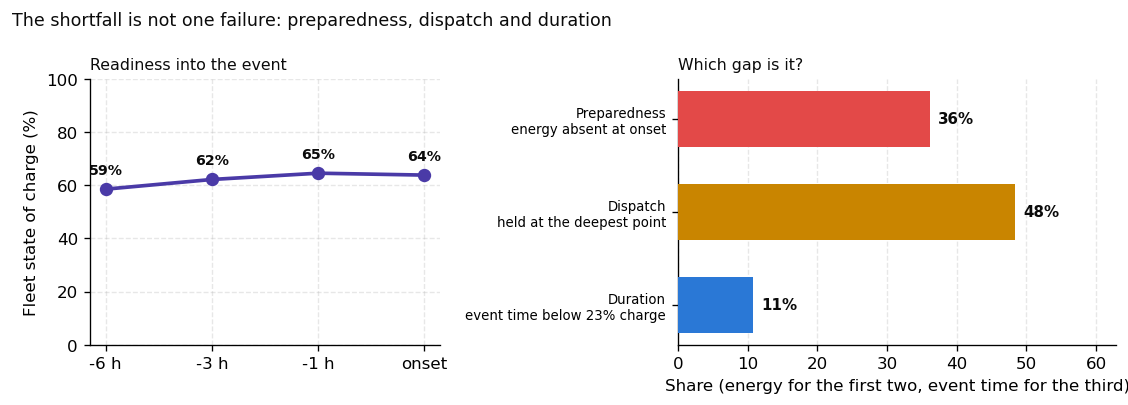


Re-anchored (daily 04:00 reset) — primary vs sensitivity:
  preparedness  36%  ->  45%
  dispatch      48%  ->  39%
  duration      11%  ->  12%
  readiness run-up 48% 53% 56% 55%  (primary 59% 62% 65% 64%)


In [19]:
# Three gaps, not one — and they call for different market instruments.
#
# "The fleet underdelivers in scarcity" hides three separate failures, each with
# its own remedy. Separating them is the point:
#
#   preparedness — the energy was not stored when the event began
#   dispatch     — the energy was there and was not delivered
#   duration     — the energy was delivered, and ran out while the event ran
#
# The first two are energy fractions of usable capacity, the third is a share of
# event time, so they are reported side by side rather than stacked: adding a
# fraction of MWh to a fraction of hours would be meaningless.
READY_OFFSETS_H = [-6, -3, -1, 0]
#: "Depleted" is the fleet's own low-water mark over the whole record — its
#: tenth percentile — not each event's minimum. Anchoring to the event minimum
#: measures flatness instead of depletion: a fleet that barely discharges sits
#: near its own minimum throughout and would score a large duration gap while
#: never running low.
DEPLETED = float(fleet_soc.quantile(0.10))

gap_rows, ready_rows = [], []
for _, ev in events_df.iterrows():
    t0 = ev["start"]
    idx = pd.date_range(t0, periods=int(ev["hours"] * 2), freq="30min", tz="UTC")
    path = fleet_soc.reindex(idx).dropna()
    if len(path) < 2:
        continue
    soc0, soc_min = path.iloc[0], path.min()
    ran_low = (path <= DEPLETED).mean()
    gap_rows.append({
        "hours": ev["hours"],
        # Energy that was not in the fleet when the system needed it.
        "preparedness": max(0.0, 1.0 - soc0),
        # Energy that was in the fleet at its deepest point and never left it.
        "dispatch": soc_min,
        # Share of the event spent below the fleet's low-water mark, still tight.
        "duration": ran_low,
    })
    ready = {}
    for h in READY_OFFSETS_H:
        v = fleet_soc.reindex([t0 + pd.Timedelta(hours=h)]).iloc[0]
        ready[h] = v
    ready_rows.append(ready)

gaps3 = pd.DataFrame(gap_rows)
ready_df = pd.DataFrame(ready_rows)
print(f"Events decomposed: {len(gaps3)}")
print(f"  preparedness gap : {gaps3['preparedness'].mean():.0%} of usable energy absent at onset")
print(f"  dispatch gap     : {gaps3['dispatch'].mean():.0%} still held at the deepest point")
print(f"  duration gap     : {gaps3['duration'].mean():.0%} of event time spent below "
      f"{DEPLETED:.0%} state of charge")
print("\nReadiness run-up (mean fleet state of charge):")
for h in READY_OFFSETS_H:
    print(f"  {h:+3d} h : {ready_df[h].mean():.0%}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.4, 3.4),
                               gridspec_kw={"width_ratios": [1, 1.25]})

x = np.arange(len(READY_OFFSETS_H))
axL.plot(x, [ready_df[h].mean() * 100 for h in READY_OFFSETS_H],
         marker="o", ms=7, lw=2.2, color=C["soc"] if "soc" in C else C["da"], zorder=3)
for i, h in enumerate(READY_OFFSETS_H):
    axL.annotate(f"{ready_df[h].mean():.0%}", (i, ready_df[h].mean() * 100),
                 xytext=(0, 9), textcoords="offset points", ha="center",
                 fontsize=8.5, fontweight="bold", color=C["ink"])
axL.set_xticks(x, [f"{h:+d} h" if h else "onset" for h in READY_OFFSETS_H])
axL.set_ylabel("Fleet state of charge (%)")
axL.set_ylim(0, 100)
axL.set_title("Readiness into the event", fontsize=9.5, loc="left", color=C["ink"])

names = ["preparedness", "dispatch", "duration"]
labels = ["Preparedness\nenergy absent at onset",
          "Dispatch\nheld at the deepest point",
          f"Duration\nevent time below {DEPLETED:.0%} charge"]
vals = [gaps3[n].mean() * 100 for n in names]
colours = [C["cost"], C["mid"], C["da"]]
y = np.arange(len(names))
axR.barh(y, vals, height=0.6, color=colours, zorder=3)
for i, v in enumerate(vals):
    axR.text(v + 1.2, i, f"{v:.0f}%", va="center", fontsize=9,
             fontweight="bold", color=C["ink"])
axR.set_yticks(y, labels, fontsize=8)
axR.invert_yaxis()
axR.grid(axis="y", visible=False)
axR.set_xlim(0, max(vals) * 1.3)
axR.set_xlabel("Share (energy for the first two, event time for the third)")
axR.set_title("Which gap is it?", fontsize=9.5, loc="left", color=C["ink"])

fig.suptitle("The shortfall is not one failure: preparedness, dispatch and duration",
             fontsize=10.5, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
# Print-resolution export for the poster: the three-part gap decomposition.
save_poster_fig(fig, "nb05_fig_gap_decomposition")

plt.show()


# Sensitivity: every number above rests on inferred state of charge, so re-run
# the decomposition on the daily-re-anchored series. These are the only poster
# figures that could flip on the inference scheme, so the disagreement is
# printed rather than assumed away.
anchor_rows = []
for _, ev in events_df.iterrows():
    t0 = ev["start"]
    idx = pd.date_range(t0, periods=int(ev["hours"] * 2), freq="30min", tz="UTC")
    path = fleet_soc_anchor.reindex(idx).dropna()
    if len(path) < 2:
        continue
    anchor_rows.append({
        "preparedness": max(0.0, 1.0 - path.iloc[0]),
        "dispatch": path.min(),
        "duration": (path <= float(fleet_soc_anchor.quantile(0.10))).mean(),
    })
g_anchor = pd.DataFrame(anchor_rows)
print("\nRe-anchored (daily 04:00 reset) — primary vs sensitivity:")
for k in ("preparedness", "dispatch", "duration"):
    print(f"  {k:13} {gaps3[k].mean():.0%}  ->  {g_anchor[k].mean():.0%}")
ready_anchor = [fleet_soc_anchor.reindex(
    [t + pd.Timedelta(hours=h) for t in events_df["start"]]).mean()
    for h in READY_OFFSETS_H]
print("  readiness run-up " + " ".join(f"{v:.0%}" for v in ready_anchor)
      + f"  (primary {' '.join(f'{ready_df[h].mean():.0%}' for h in READY_OFFSETS_H)})")


Site-periods under critical margin: 43,239 across 82 sites
  discharging above 25% of nameplate : 17.3% of site-periods
  discharging above 50% of nameplate : 11.1% of site-periods
  discharging above 75% of nameplate : 6.5% of site-periods


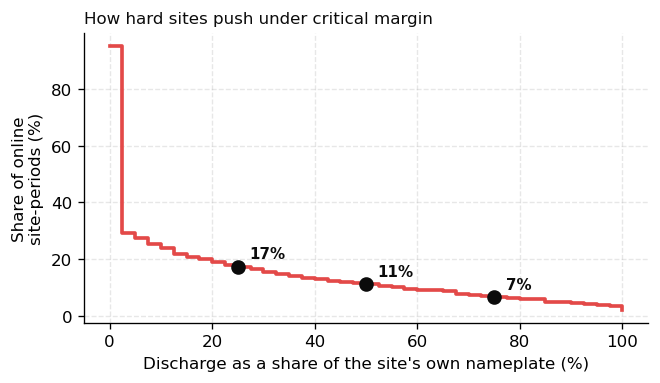

In [20]:
# "+0.051 MW/MW is only 5%" — what does that mean site by site?
#
# A fleet mean hides the distribution. Under critical margin the question a
# reviewer actually asks is how many sites are pushing hard, not what the
# average is. This is the exceedance curve: the share of online sites
# discharging above a given fraction of their own nameplate.
EXCEED_LEVELS = [0.25, 0.50, 0.75]

crit_idx = grid[CRITICAL]
depth_rows = []
for site in wide.columns:
    mw_site = SITE_MW.get(site, 0.0)
    if mw_site <= 0:
        continue
    frac = (wide[site].reindex(crit_idx) / mw_site).dropna()
    if frac.empty:
        continue
    depth_rows.append(frac.rename(site))

depth = pd.concat(depth_rows, axis=1) if depth_rows else pd.DataFrame()
online = depth.notna()
print(f"Site-periods under critical margin: {int(online.sum().sum()):,} "
      f"across {depth.shape[1]} sites")
for lvl in EXCEED_LEVELS:
    share = (depth >= lvl).sum().sum() / max(online.sum().sum(), 1)
    print(f"  discharging above {lvl:.0%} of nameplate : {share:.1%} of site-periods")

xs = np.linspace(0, 1, 41)
ys = [(depth >= x).sum().sum() / max(online.sum().sum(), 1) * 100 for x in xs]
fig, ax = plt.subplots(figsize=(5.6, 3.3))
ax.step(xs * 100, ys, where="post", lw=2.2, color=C["cost"], zorder=3)
for lvl in EXCEED_LEVELS:
    v = (depth >= lvl).sum().sum() / max(online.sum().sum(), 1) * 100
    ax.scatter([lvl * 100], [v], s=60, color=C["ink"], zorder=4)
    ax.annotate(f"{v:.0f}%", (lvl * 100, v), xytext=(7, 5),
                textcoords="offset points", fontsize=9, fontweight="bold",
                color=C["ink"])
ax.set_xlabel("Discharge as a share of the site's own nameplate (%)")
ax.set_ylabel("Share of online\nsite-periods (%)")
ax.set_title("How hard sites push under critical margin", fontsize=10,
             loc="left", color=C["ink"])
plt.tight_layout()
# Print-resolution export for the poster: response depth under critical margin.
save_poster_fig(fig, "nb05_fig_response_depth")

plt.show()


       sites        mw  response   soc
band                                  
< 1 h      9   515.410     0.057 0.568
1-2 h     26 2,407.714     0.135 0.390
2-4 h     20 1,612.300     0.085 0.488


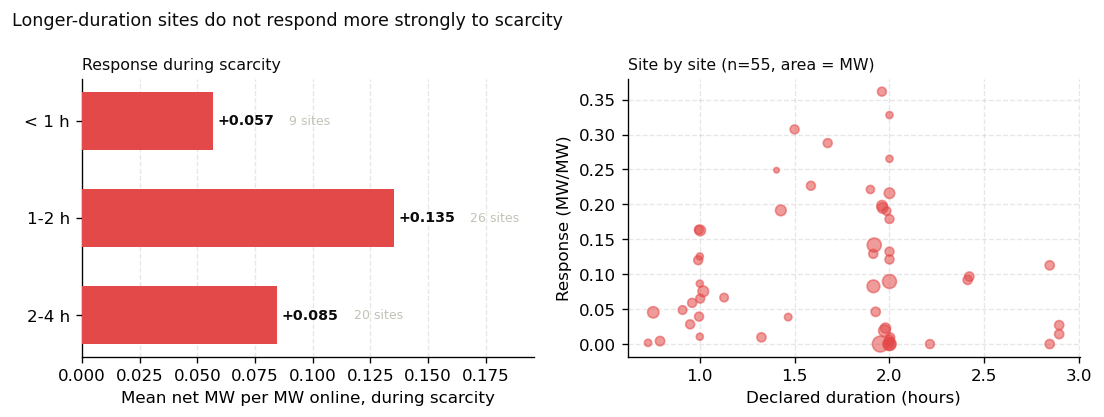


Correlation, declared duration vs response: +0.03 (n=55 sites)


In [21]:
# Figure — is the alignment gap a market-incentive gap or a physical one?
#
# The counterfactual runs a 50 MW / 2 h battery. If the gap is really about
# duration rather than timing, then how long a real site can run should predict
# how well it covers a scarcity event. This segments the observed fleet by
# declared energy/power and asks the same questions of each band.
DURATION_BANDS = [(0.0, 1.0, "< 1 h"), (1.0, 2.0, "1-2 h"),
                  (2.0, 4.0, "2-4 h"), (4.0, 99.0, "4 h +")]

site_hours = {s: SITE_MWH[s] / SITE_MW[s]
              for s in SITE_MWH
              if SITE_MWH.get(s) == SITE_MWH.get(s)     # not NaN
              and SITE_MW.get(s, 0) > 0}

def _band(h):
    for lo, hi, name in DURATION_BANDS:
        if lo <= h < hi:
            return name
    return None

crit_mask = pd.Series(CRITICAL, index=grid).fillna(False)
dur_rows = []
for site, hours in site_hours.items():
    name = _band(hours)
    if name is None or site not in wide.columns:
        continue
    mw_site = SITE_MW.get(site, 0.0)
    if mw_site <= 0:
        continue
    net = wide[site].reindex(grid) / mw_site       # MW per MW of site capacity
    during = net[crit_mask]
    if during.notna().sum() < 30:                  # too thin to characterise
        continue
    soc_site = soc_df[site].reindex(grid) if site in soc_df.columns else pd.Series(dtype=float)
    dur_rows.append({
        "site": site, "band": name, "hours": hours, "mw": mw_site,
        "response": during.mean(),
        "soc_at_stress": soc_site[crit_mask].mean() if len(soc_site) else np.nan,
        "n": int(during.notna().sum()),
    })

dur_df = pd.DataFrame(dur_rows)
order = [n for _, _, n in DURATION_BANDS if n in set(dur_df["band"])]
summary = (dur_df.groupby("band")
           .agg(sites=("site", "size"), mw=("mw", "sum"),
                response=("response", "mean"), soc=("soc_at_stress", "mean"))
           .reindex(order))
print(summary.to_string(float_format=lambda v: f"{v:,.3f}"))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.2, 3.5),
                               gridspec_kw={"width_ratios": [1, 1]})
y = np.arange(len(summary))
axL.barh(y, summary["response"], height=0.6, color=C["cost"], zorder=3)
for i, (v, n) in enumerate(zip(summary["response"], summary["sites"])):
    axL.text(v + 0.002, i, f"{v:+.3f}", va="center", fontsize=8.5,
             fontweight="bold", color=C["ink"])
    axL.annotate(f"{n} sites", (v, i), xytext=(46, 0), textcoords="offset points",
                 va="center", fontsize=7.5, color=C["ghost"])
axL.set_yticks(y, summary.index)
axL.invert_yaxis()
axL.grid(axis="y", visible=False)
axL.set_xlim(0, max(summary["response"].max() * 1.45, 0.01))
axL.set_xlabel("Mean net MW per MW online, during scarcity")
axL.set_title("Response during scarcity", fontsize=9.5, loc="left", color=C["ink"])

axR.scatter(dur_df["hours"], dur_df["response"], s=np.sqrt(dur_df["mw"]) * 4.0,
            color=C["cost"], alpha=0.55, zorder=3)
axR.set_xlabel("Declared duration (hours)")
axR.set_ylabel("Response (MW/MW)")
axR.set_title(f"Site by site (n={len(dur_df)}, area = MW)", fontsize=9.5,
              loc="left", color=C["ink"])
fig.suptitle("Longer-duration sites do not respond more strongly to scarcity",
             fontsize=10.5, x=0.005, ha="left", color=C["ink"])
plt.tight_layout()
# Print-resolution export for the poster: response by declared duration.
save_poster_fig(fig, "nb05_fig_response_by_duration")

plt.show()

if len(dur_df) > 5:
    r = dur_df[["hours", "response"]].corr().iloc[0, 1]
    print(f"\nCorrelation, declared duration vs response: {r:+.2f} (n={len(dur_df)} sites)")


Triggered events: 515 | median lead from trigger to the period: 11.9 h


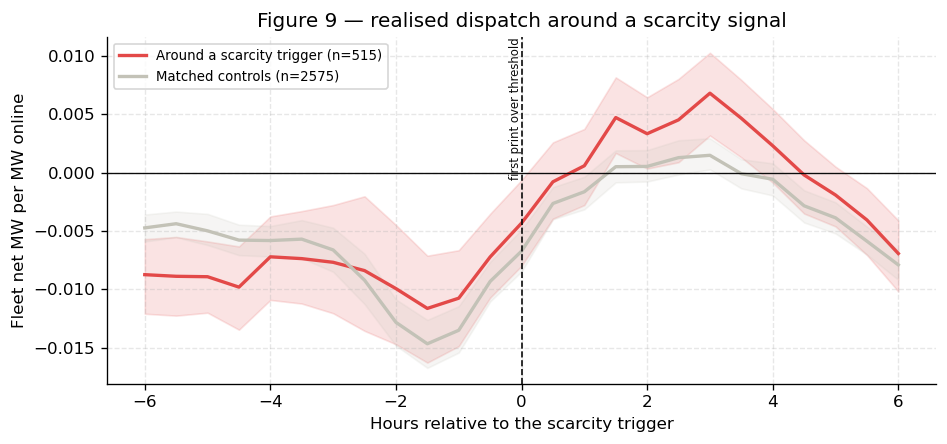

Mean net response in the 4 h after the trigger: +0.002 MW/MW vs -0.001 in controls


In [22]:
trig = prints[(prints["drm_mw"] < DRM_CRITICAL_MW) | (prints["lolp"] > 0)]
trigger_time = trig.groupby("time")["publish_time"].min()

events = [t for t in onsets if t in trigger_time.index]
if not events:
    skip("no critical period carried an advance trigger print — event study unavailable")
else:
    ev_rows, ct_rows = [], []
    for t0 in events:
        t_trig = trigger_time[t0].floor("30min")
        lead = t0 - t_trig
        ev_rows.append(t_trig)
        for c0 in matched_controls(t0):
            ct_rows.append(c0 - lead)

    ev_prof = trajectory(norm_net, ev_rows, back=EVENT_HH, fwd=EVENT_HH)
    ct_prof = trajectory(norm_net, ct_rows, back=EVENT_HH, fwd=EVENT_HH)
    leads = pd.Series([(t0 - trigger_time[t0]).total_seconds() / 3600 for t0 in events])
    print(f"Triggered events: {len(events)} | median lead from trigger to the period: "
          f"{leads.median():.1f} h")

    fig, ax = plt.subplots(figsize=(8, 3.8))
    x = ev_prof.columns.astype(float)
    for frame, colour, name in ((ev_prof, C["cost"], f"Around a scarcity trigger (n={len(ev_prof)})"),
                                (ct_prof, C["ghost"], f"Matched controls (n={len(ct_prof)})")):
        if not len(frame):
            continue
        ax.plot(x, np.nanmean(frame.values, axis=0), color=colour, lw=2, label=name)
        lo, hi = boot_ci(frame)
        if lo is not None:
            ax.fill_between(x, lo, hi, color=colour, alpha=0.15)
    ax.axvline(0, color=C["ink"], lw=1, ls="--")
    ax.annotate("first print over threshold", (0, ax.get_ylim()[1]), fontsize=7,
                rotation=90, va="top", ha="right", color=C["ink"])
    ax.axhline(0, color=C["ink"], lw=0.8)
    ax.set_xlabel("Hours relative to the scarcity trigger")
    ax.set_ylabel("Fleet net MW per MW online")
    ax.legend(fontsize=8)
    ax.set_title("Figure 9 — realised dispatch around a scarcity signal")
    plt.tight_layout()
    plt.show()

    post = ev_prof[[c for c in ev_prof.columns if 0 <= c <= 4]]
    post_c = ct_prof[[c for c in ct_prof.columns if 0 <= c <= 4]]
    print(f"Mean net response in the 4 h after the trigger: "
          f"{np.nanmean(post.values):+.3f} MW/MW vs {np.nanmean(post_c.values):+.3f} in controls")

## 7. RQ4 — Consumer value: does fleet discharge suppress cashout spikes?

Batteries discharge *because* prices spike, so a naive comparison would simply rediscover that
high prices and high discharge coincide. The design here holds system stress constant: within
each de-rated-margin band, periods are split into fleet-discharge quartiles and spike
frequencies compared across them. Two periods in the same band faced comparable physical
tightness, so the residual difference is the fleet's contribution — **associationally**, and
with the reverse-causality caveat still live.

GB has run a single cashout price since 2015, so the system buy price alone describes the
imbalance market.

RQ4 — cashout spikes by margin band and fleet-discharge quartile
                       n  mean_sbp   p95_sbp  pct_over_500  pct_over_1000
band   quartile                                                          
<1,000 Q1            9.0   360.646   624.310         0.444          0.000
       Q2            9.0   479.027   826.563         0.556          0.000
       Q3            7.0   120.714   180.000         0.000          0.000
       Q4            9.0   618.210  2028.605         0.333          0.222
1–2k   Q1           62.0   323.001  1425.000         0.194          0.081
       Q2           51.0   499.074  3073.700         0.255          0.078
       Q3           56.0   316.073   996.250         0.214          0.018
       Q4           57.0   775.571  3916.280         0.368          0.158
2–4k   Q1          701.0   220.651   625.000         0.113          0.014
       Q2          759.0   248.794   627.143         0.104          0.012
       Q3          660.0   181.378   573.001   

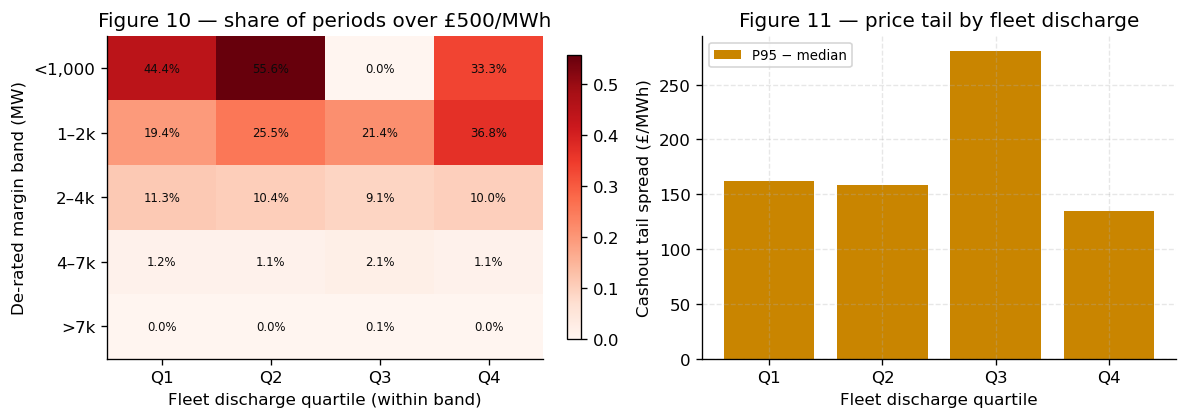

In [23]:
def _qcut(values, q, labels):
    """qcut that returns None instead of raising when the data cannot be split.

    ``duplicates="drop"`` removes tied bin edges, which then no longer match the
    label count and raises. That is a real condition here rather than an edge
    case: over eight winters the early quarters contain long runs of identical
    fleet positions — a handful of sites, several of them idle — so a decile can
    genuinely have fewer distinct quantiles than the split asks for. The
    surrounding code already means to skip those; this lets it.
    """
    try:
        binned = pd.qcut(values, q, labels=labels, duplicates="drop")
    except ValueError:
        return None
    return binned if binned.nunique() == len(labels) else None


price = sbp["system_buy_price"].reindex(grid) if "system_buy_price" in sbp.columns else pd.Series(dtype=float)
rq4 = pd.DataFrame({"drm": drm, "sbp": price, "norm": norm_net, "net": fleet_net}).dropna()

if rq4.empty:
    skip("no period has DRM, cashout price and fleet data together")
    vdi = np.nan
else:
    rq4["band"] = pd.cut(rq4["drm"], DRM_BANDS, labels=DRM_BAND_LABELS, right=False)
    def _quartile(s):
        binned = _qcut(s, 4, ["Q1", "Q2", "Q3", "Q4"])
        return pd.Series("—", index=s.index) if binned is None else binned

    rq4["quartile"] = rq4.groupby("band", observed=True)["norm"].transform(_quartile)

    def spike_stats(g):
        return pd.Series({
            "n": len(g),
            "mean_sbp": g["sbp"].mean(),
            "p95_sbp": g["sbp"].quantile(0.95),
            f"pct_over_{int(SPIKE_LEVELS[0])}": (g["sbp"] > SPIKE_LEVELS[0]).mean(),
            f"pct_over_{int(SPIKE_LEVELS[1])}": (g["sbp"] > SPIKE_LEVELS[1]).mean(),
        })

    table = rq4.groupby(["band", "quartile"], observed=True).apply(spike_stats,
                                                                  include_groups=False)
    print("RQ4 — cashout spikes by margin band and fleet-discharge quartile")
    print(table.round(3).to_string())

    # Volatility Dampening Index: tail compression at equal stress.
    rq4["drm_decile"] = pd.qcut(rq4["drm"], 10, labels=False, duplicates="drop")
    parts, weights = [], []
    for _, g in rq4.groupby("drm_decile", observed=True):
        if g["norm"].nunique() < 3 or len(g) < 30:
            continue
        terciles = _qcut(g["norm"], 3, ["low", "mid", "high"])
        if terciles is None:
            continue
        lo = g.loc[terciles == "low", "sbp"]
        hi = g.loc[terciles == "high", "sbp"]
        parts.append((lo.quantile(0.95) - lo.quantile(0.5))
                     - (hi.quantile(0.95) - hi.quantile(0.5)))
        weights.append(len(g))
    vdi = float(np.average(parts, weights=weights)) if parts else np.nan
    print(f"\nVolatility Dampening Index: "
          f"{'—' if np.isnan(vdi) else f'£{vdi:,.0f}/MWh'} "
          f"(positive ⇒ tails compressed when the fleet discharges, at equal stress; "
          f"{len(parts)} margin deciles used)")

    heat = table[f"pct_over_{int(SPIKE_LEVELS[0])}"].unstack("quartile")
    if heat.notna().any().any() and heat.shape[1] > 1:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
        ax = axes[0]
        im = ax.imshow(heat.values, cmap="Reds", aspect="auto")
        ax.set_xticks(range(heat.shape[1])); ax.set_xticklabels(heat.columns)
        ax.set_yticks(range(heat.shape[0])); ax.set_yticklabels(heat.index)
        for i in range(heat.shape[0]):
            for j in range(heat.shape[1]):
                v = heat.values[i, j]
                if pd.notna(v):
                    ax.annotate(f"{v:.1%}", (j, i), ha="center", va="center", fontsize=7,
                                color=C["ink"])
        ax.set_xlabel("Fleet discharge quartile (within band)")
        ax.set_ylabel("De-rated margin band (MW)")
        ax.set_title(f"Figure 10 — share of periods over £{SPIKE_LEVELS[0]:,.0f}/MWh")
        ax.grid(False)
        fig.colorbar(im, ax=ax, fraction=0.03)

        ax = axes[1]
        by_q = rq4.groupby("quartile", observed=True)["sbp"].agg(
            **{"median": "median", "p95": lambda s: s.quantile(0.95)})
        idx = range(len(by_q))
        ax.bar(idx, by_q["p95"] - by_q["median"], color=C["mid"], label="P95 − median")
        ax.set_xticks(list(idx)); ax.set_xticklabels(by_q.index)
        ax.set_xlabel("Fleet discharge quartile")
        ax.set_ylabel("Cashout tail spread (£/MWh)")
        ax.set_title("Figure 11 — price tail by fleet discharge")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        skip("not enough within-band variation in fleet discharge to form quartiles")

## 8. Limitations

1. **Physical Notifications are final-only.** Elexon does not publish PN revision history, so
   Section 6 measures realised dispatch around a scarcity signal. It cannot show an operator
   changing plan, and must not be read as proof of reaction.
2. **State of charge is inferred, never observed.** It integrates PN power against approximate
   nameplate energy, and is computed only for sites whose energy capacity is actually
   published; ancillary throughput and any trading not reflected in PNs are invisible.
   The usability filter and the daily-re-anchor sensitivity bound the damage rather than
   remove it.
3. **The population is the BM-registered census, and its edge is measured.** Every
   BM-registered GB battery site identified in notebook 06 — 87 sites, 124 BM Units — not the
   smaller population the live dashboard renders. Two limits remain and neither is
   closable from public data. *Aggregator-traded batteries are structurally invisible*: a unit
   trading behind a VLP or supplier portfolio has no per-BMU feed, and on recent auction
   results those portfolios take roughly half of all battery ancillary revenue, so a material
   share of the fleet cannot be seen at site level by any method here. *Energy capacity is
   published only through Capacity Market agreements*, which match a BM Unit for a minority of
   sites, so state-of-charge and cycle figures are computed over the known-MWh subset and say
   so; MW-normalised figures span the whole census.
4. **The trend in 4b is conditioned on relative tightness, not scarcity.** It measures response
   to each quarter's own tightest decile, which is what makes it comparable across seasons, and
   it is not evidence of scarcity reliability. The operator-grade series over the same window is
   non-monotonic and tracks how much scarcity each winter held (correlation −0.85 between a
   winter's qualifying-period count and the fleet's average response), consistent with
   duration-limited assets running out of energy rather than declining willingness.
   The full-window composition panel is three sites — a case study, not a control.
5. **Fleet composition drifts hard.** The tracked fleet roughly doubles across the window, so
   every fleet statistic is normalised per MW online; absolute-MW comparisons across years are
   not meaningful.
6. **RQ4 is associational.** Batteries discharge because prices spike. Matching within
   de-rated-margin bands holds physical stress roughly constant, but does not identify a causal
   effect, and the consumer-cost framing is illustrative only.
7. **Rare events are rare.** Loss-of-load probability is zero in the overwhelming majority of
   periods and Capacity Market Notices number in the single digits. Every statistic reports its
   n; the notice analysis is explicitly a set of case studies.
8. **MELS is declared capability, not proven output.** A unit can declare availability it
   would struggle to deliver; the availability factor measures what the operator could see.
9. **Residual load is transmission-metered.** Embedded generation nets off before it is
   observed, which is why the operator-grade signals (LoLP, DRM, CMN) carry the stress
   definitions here and the residual-load decile is kept only as the tier-1 comparator.

In [24]:
def _fmt(row, col, fmt="{:+.3f}"):
    return "—" if row is None or col not in row or pd.isna(row[col]) else fmt.format(row[col])


print("=" * 72)
print("  STRESS RESPONSE STUDY — HEADLINE NUMBERS")
print("=" * 72)
print(f"  Window                     : {WINDOW_START} → {WINDOW_END} ({len(DAYS)} days)")
print(f"  Classified half-hours      : {len(grid):,}  ({int(known.sum()):,} with LoLP/DRM)")
print(f"  Tracked fleet              : {online_mw.iloc[0]:,.0f} → {online_mw.iloc[-1]:,.0f} MW "
      f"({int(online_n.iloc[-1])} sites)")
print("-" * 72)
print(f"  RQ1  Fleet net, all periods: {_fmt(rq1.loc['All periods'], 'net_MW_per_MW')} MW/MW online")
for name in ("LoLP >= 1e-4", "DRM < 1 GW", "CMN issued"):
    row = rq1.loc[name]
    if row["n"] == 0:
        print(f"       {name:<22}: n=0 (no such period in window)")
        continue
    print(f"       {name:<22}: {_fmt(row, 'net_MW_per_MW')} MW/MW · "
          f"availability {_fmt(row, 'avail_factor', '{:.0%}')} · "
          f"SoC {_fmt(row, 'mean_SoC', '{:.0%}')} · n={int(row['n'])}")
print("-" * 72)
if not rq2.empty and rq2.iloc[0]["n"] > 0:
    t = rq2.iloc[0]
    print(f"  RQ2  DRM < 1 GW (n={int(t['n'])})    : fleet charging in "
          f"{t['charging_share']:.0%} of periods, mean net {t['mean_net_MW']:+,.0f} MW")
else:
    print("  RQ2  DRM < 1 GW            : n=0 in window")
print("-" * 72)
if len(warning_h.dropna()):
    seen = warning_h.dropna()
    print(f"  RQ3  Advance visibility    : {len(seen)}/{len(warning_h)} critical periods "
          f"({len(seen) / max(len(warning_h), 1):.0%}), median {seen.median():.0f} h of warning")
else:
    print("  RQ3  Advance visibility    : no critical period with prints")
if len(USABLE_SOC) and len(onsets):
    print(f"       SoC at onset vs control: {np.nanmean(ev_soc[0.0]):.0%} vs "
          f"{np.nanmean(ct_soc[0.0]):.0%}")
if not cmn_issued.empty:
    print(f"       CMNs issued / standing at delivery: {len(cmn_issued)} / {survived}")
print("-" * 72)
if not rq4.empty:
    over = rq4[f"sbp"].gt(SPIKE_LEVELS[0]).mean()
    print(f"  RQ4  Cashout > £{SPIKE_LEVELS[0]:,.0f}/MWh   : {over:.2%} of all periods")
    print(f"       Volatility Dampening  : "
          f"{'—' if np.isnan(vdi) else f'£{vdi:,.0f}/MWh tail compression'}")
else:
    print("  RQ4  Cashout analysis      : unavailable (missing price or fleet data)")
print("=" * 72)
print("  Fleet statistics are normalised per MW online; SoC is inferred from PNs.")
print("  See Section 8 for the limitations these numbers must be read with.")
print("=" * 72)

  STRESS RESPONSE STUDY — HEADLINE NUMBERS
  Window                     : 2018-01-01 → 2026-08-24 (3158 days)
  Classified half-hours      : 150,843  (150,672 with LoLP/DRM)
  Tracked fleet              : 68 → 5,972 MW (80 sites)
------------------------------------------------------------------------
  RQ1  Fleet net, all periods: +0.003 MW/MW online
       LoLP >= 1e-4          : +0.060 MW/MW · availability 41% · SoC 57% · n=2075
       DRM < 1 GW            : +0.051 MW/MW · availability 46% · SoC 64% · n=39
       CMN issued            : +0.099 MW/MW · availability 40% · SoC 56% · n=13
------------------------------------------------------------------------
  RQ2  DRM < 1 GW (n=34)    : fleet charging in 3% of periods, mean net +56 MW
------------------------------------------------------------------------
  RQ3  Advance visibility    : 2076/2076 critical periods (100%), median 12 h of warning
       SoC at onset vs control: 62% vs 63%
       CMNs issued / standing at delivery: 13 /

In [25]:
# Poster numbers, published rather than retyped. See notebook 06's export cell
# for why: the poster reads these, so it cannot quote a stale figure.
import json

from research.figexport import save_poster_metrics

_drm = rq1.loc["DRM < 1 GW"]
_base = rq1.loc["All periods"]
_half = (depth >= 0.50).sum().sum() / max(online.sum().sum(), 1)

nb05_metrics = {
    "drm_threshold": "< 1 GW",
    "discharge_share": f"{_drm['discharging_%']:.0%}",
    "response": f"{_drm['net_MW_per_MW']:+.3f} MW per MW online",
    "baseline": f"{_base['net_MW_per_MW']:+.3f}",
    "tail_half": f"{_half:.0%}",
    "events": f"{len(gaps3)}",
    "duration_gap": f"{gaps3['duration'].mean():.0%}",
    "dispatch_gap": f"{gaps3['dispatch'].mean():.0%}",
    "preparedness_gap": f"{gaps3['preparedness'].mean():.0%}",
    "soc_at_onset": f"{events_df['soc_at_onset'].median():.0%}",
    "dispatch_multiple": f"{gaps3['dispatch'].mean() / max(gaps3['duration'].mean(), 1e-9):.0f}x",
    "dur_corr": f"r = {r:+.2f}",
    "dur_sites": f"{len(dur_df)}",
    # Sample sizes the poster quotes when it warns how thin these sets are.
    "n_cmn": f"{int(rq1.loc['CMN issued', 'n'])}",
    "n_drm": f"{int(_drm['n'])}",
}
print(json.dumps(nb05_metrics, indent=2))
save_poster_metrics("nb05", nb05_metrics)


{
  "drm_threshold": "< 1 GW",
  "discharge_share": "95%",
  "response": "+0.051 MW per MW online",
  "baseline": "+0.003",
  "tail_half": "11%",
  "events": "428",
  "duration_gap": "11%",
  "dispatch_gap": "48%",
  "preparedness_gap": "36%",
  "soc_at_onset": "61%",
  "dispatch_multiple": "4x",
  "dur_corr": "r = +0.03",
  "dur_sites": "55",
  "n_cmn": "13",
  "n_drm": "39"
}


PosixPath('/Users/abhinav/Documents/code/power-trading/reports/figures/poster/nb05_metrics.json')

---

## Read with notebook 10 — these figures are notifications, not delivery

Everything above is measured from Final Physical Notifications: what each unit told the
operator it intended to do at gate closure. The Balancing Mechanism then instructs it away
from that plan, and for GB batteries the accepted volume is of the same order as the notified
position.

Notebook 10 reruns these results on the corrected series (`fleet_boa`, the notification with
acceptances painted over it). **For this notebook the correction is small** — response
+0.060 → +0.056 on the LoLP set, charge at onset about two points — so the readiness finding
stands as written. It is *not* small for notebook 09's delivery figures. Do not carry a
delivery claim from here to there without checking notebook 10 first.